In [1]:
# notebook for testing out new TJ river flow maker...
import sys
import os
import subprocess
import shutil
import numpy as np
import netCDF4 as nc
import matplotlib.pyplot as plt
import gsw
import pickle
import glob
import urllib.request
from urllib.error import URLError, HTTPError
from datetime import datetime, timedelta, date

sys.path.append('../sdpm_py_util')
import init_funs_forecast as initfuns
import run_funs as runfuns
import util_functions as utilfuns
import river_functions as riverfuns
import ocn_funs_forecast as ocnfuns
import swan_functions as swanfuns
import run_funs as runfuns
sys.path.append('/home/mspydell/models/PFM_root/PFM/driver')
import driver_functions as driverfuns
#from driver_run_forecast_LV1234 import driver_run_fore_LV1234
from driver_run_pfm_phm import driver_run_pfm_phm
import gc



In [2]:
fn_riv_nc = '/scratch/PFM_Simulations/LV4_Forecast/Forc/LV4_river.nc'
ds = nc.Dataset(fn_riv_nc)
print(ds)

<class 'netCDF4.Dataset'>
root group (NETCDF4 data model, file format HDF5):
    type: river and tracer file for roms PFM
    author: matthew spydell
    note: similar to XWu river_tracer.nc file.
    dimensions(sizes): river(9), s_rho(10), river_time(123)
    variables(dimensions): float64 theta_s(), float64 theta_b(), float64 Tcline(), float64 hc(), float64 river(river), int64 river_Xposition(river), int64 river_Eposition(river), int64 river_direction(river), float64 river_flag(river), float64 river_Vshape(s_rho, river), float64 river_transport(river_time, river), float64 river_temp(river_time, s_rho, river), float64 river_salt(river_time, s_rho, river), float64 river_dye_01(river_time, s_rho, river), float64 river_dye_02(river_time, s_rho, river), float64 Cs_r(s_rho), float64 river_time(river_time)
    groups: 


making river tracer dictionary
making the river discharge pickle file
using the new method to get river flow from nwm
using make_nwm_q_pkl_file
trying to use  /scratch/PFM_Simulations/nwm_ncs/nwm_forecast_Q_2026011400.nc
we did not have the file. trying to make  /scratch/PFM_Simulations/nwm_ncs/nwm_forecast_Q_2026011400.nc
testing for nwm files...
for,  https://nomads.ncep.noaa.gov/pub/data/nccf/com/nwm/v3.0/nwm.20260114/medium_range_blend/nwm.t00z.medium_range_blend.channel_rt.f001.conus.nc
double checking whether nwm has data now.
for,  https://nomads.ncep.noaa.gov/pub/data/nccf/com/nwm/v3.0/nwm.20260114/medium_range_blend/nwm.t00z.medium_range_blend.channel_rt.f002.conus.nc
double checking whether nwm has data now.
for,  https://nomads.ncep.noaa.gov/pub/data/nccf/com/nwm/v3.0/nwm.20260114/medium_range_blend/nwm.t00z.medium_range_blend.channel_rt.f003.conus.nc
double checking whether nwm has data now.
for,  https://nomads.ncep.noaa.gov/pub/data/nccf/com/nwm/v3.0/nwm.20260114/medium_r

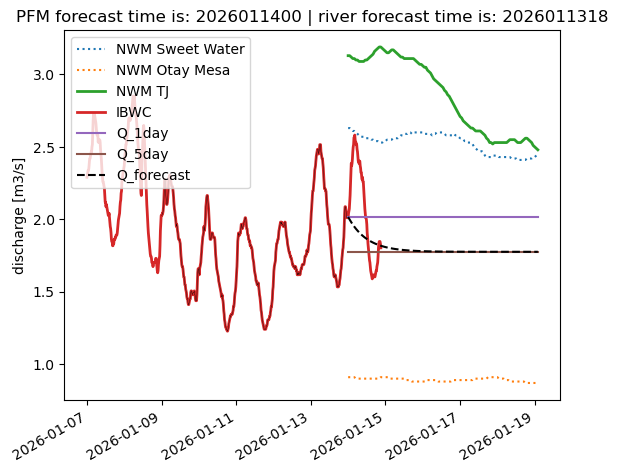

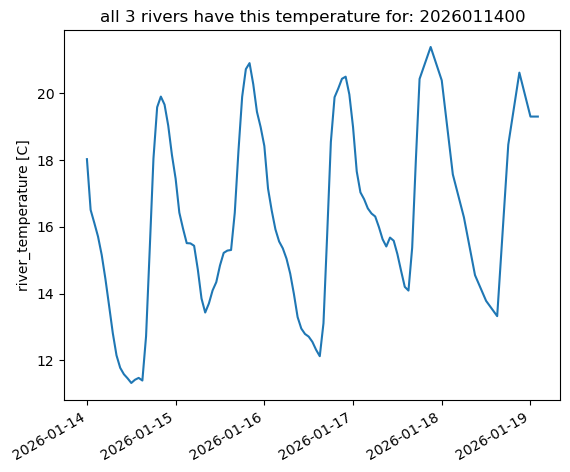

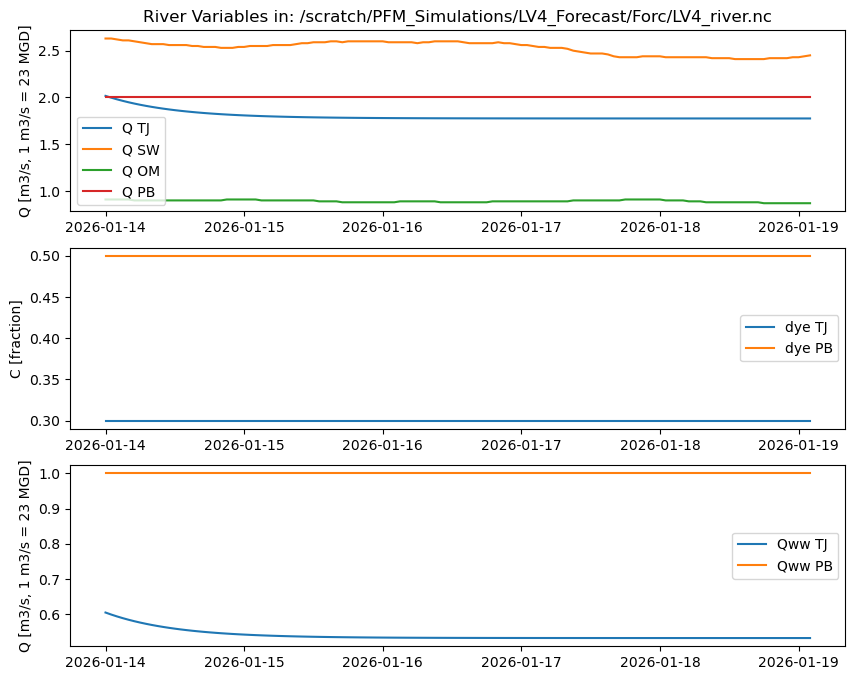

In [3]:
pkl_fnm = "/scratch/PFM_Simulations/forecast_info.pkl"
#cmd_list = ['python','-u','-W','ignore','ocn_funs_forecast.py','mk_lv4_river_nc',pkl_fnm]
#ret3 = subprocess.run(cmd_list)   
ocnfuns.mk_lv4_river_nc(pkl_fnm)


In [ ]:

fn1 = '/scratch/PFM_Simulations/LV1_Forecast/Forc/LV1_ATM_FORCING.nc'
fn4 = '/scratch/PFM_Simulations/LV4_Forecast/Forc/LV4_ATM_FORCING.nc'

ds = nc.Dataset(fn1)
lat = ds.variables['lat'][:]
lon = ds.variables['lon'][:]
swrad = ds.variables['swrad'][-2,:,:]

fig, ax = plt.subplots()
cf = ax.contourf(lon,lat,swrad,levels=15,cmap='viridis')
ax.set_title('LV1 swrad')
ax.set_xlabel('lon')
ax.set_ylabel('lat')
fig.colorbar(cf, ax=ax, label='W/m2')

ds = nc.Dataset(fn4)
lat = ds.variables['lat'][:]
lon = ds.variables['lon'][:]
swrad = ds.variables['swrad'][-2,:,:]

fig, ax = plt.subplots()
cf = ax.contourf(lon,lat,swrad,levels=15,cmap='viridis')
ax.set_title('LV4 swrad')
ax.set_xlabel('lon')
ax.set_ylabel('lat')
fig.colorbar(cf, ax=ax, label='W/m2')



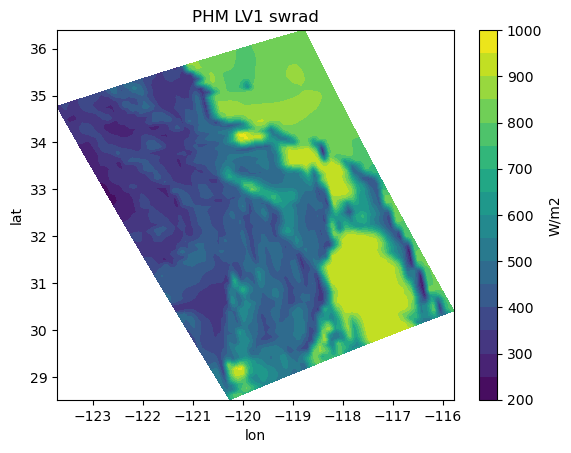

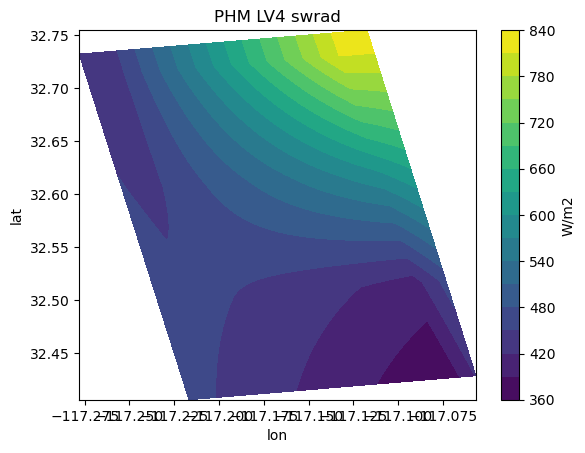

In [15]:
fn1 = '/scratch/PHM_Simulations/riv_vpfm/LV1_Forecast/Forc/LV1_ATM_FORCING.nc'
fn4 = '/scratch/PHM_Simulations/riv_vpfm/LV4_Forecast/Forc/LV4_ATM_FORCING.nc'

ds = nc.Dataset(fn1)
lat = ds.variables['lat'][:]
lon = ds.variables['lon'][:]
swrad = ds.variables['swrad'][7,:,:]

fig, ax = plt.subplots()
cf = ax.contourf(lon,lat,swrad,levels=15,cmap='viridis')
ax.set_title('PHM LV1 swrad')
ax.set_xlabel('lon')
ax.set_ylabel('lat')
fig.colorbar(cf, ax=ax, label='W/m2')

ds = nc.Dataset(fn4)
lat = ds.variables['lat'][:]
lon = ds.variables['lon'][:]
swrad = ds.variables['swrad'][7,:,:]

fig, ax = plt.subplots()
cf = ax.contourf(lon,lat,swrad,levels=15,cmap='viridis')
ax.set_title('PHM LV4 swrad')
ax.set_xlabel('lon')
ax.set_ylabel('lat')
fig.colorbar(cf, ax=ax, label='W/m2')


In [3]:
dir0 = '/dataSIO/PHM_Simulations/riv_nwm/LV4/'
dates = ['0604','0605','0606']
fns = []
for date in dates:
    fns.append(dir0+'LV4_ocean_his_2025'+date+'0000.nc')

print(fns)

vars = ['zeta']

data = load_PHM_2d_data_from_nc_slice(fns[1],vars,'lat',0)


['/dataSIO/PHM_Simulations/riv_nwm/LV4/LV4_ocean_his_202506040000.nc', '/dataSIO/PHM_Simulations/riv_nwm/LV4/LV4_ocean_his_202506050000.nc', '/dataSIO/PHM_Simulations/riv_nwm/LV4/LV4_ocean_his_202506060000.nc']


In [ ]:
print(data)

{'time': array([datetime.datetime(2025, 6, 5, 0, 0),
       datetime.datetime(2025, 6, 5, 1, 0),
       datetime.datetime(2025, 6, 5, 2, 0),
       datetime.datetime(2025, 6, 5, 3, 0),
       datetime.datetime(2025, 6, 5, 4, 0),
       datetime.datetime(2025, 6, 5, 5, 0),
       datetime.datetime(2025, 6, 5, 6, 0),
       datetime.datetime(2025, 6, 5, 7, 0),
       datetime.datetime(2025, 6, 5, 8, 0),
       datetime.datetime(2025, 6, 5, 9, 0),
       datetime.datetime(2025, 6, 5, 10, 0),
       datetime.datetime(2025, 6, 5, 11, 0),
       datetime.datetime(2025, 6, 5, 12, 0),
       datetime.datetime(2025, 6, 5, 13, 0),
       datetime.datetime(2025, 6, 5, 14, 0),
       datetime.datetime(2025, 6, 5, 15, 0),
       datetime.datetime(2025, 6, 5, 16, 0),
       datetime.datetime(2025, 6, 5, 17, 0),
       datetime.datetime(2025, 6, 5, 18, 0),
       datetime.datetime(2025, 6, 5, 19, 0),
       datetime.datetime(2025, 6, 5, 20, 0),
       datetime.datetime(2025, 6, 5, 21, 0),
       date

: 

In [2]:
t1str = '2025081500'
t2str = '2025090200'
info_pkl="/scratch/PHM_Simulations/phm_vpfm.pkl"
#cmd_list, ncs = ocnfuns.get_hind_nc_cmd_list(t1str,t2str,info_pkl)

#print(cmd_list[0])
#print(ncs)

ocnfuns.get_hycom_hind_data(t1str,t2str,info_pkl)


we need  1013  hycom nc files...
some, but not all nc files are missing, we will try and get them...
we are getting 2 .nc files...
getting  2  hycom files...


KeyboardInterrupt: 

<class 'netCDF4.Variable'>
float64 ocean_time(ocean_time)
    long_name: time since initialization
    units: seconds since 1999-01-01 00:00:00
    calendar: proleptic_gregorian
    field: time, scalar, series
unlimited dimensions: ocean_time
current shape = (4,)
filling on, default _FillValue of 9.969209968386869e+36 used
[datetime.datetime(2025, 3, 13, 6, 0)
 datetime.datetime(2025, 3, 13, 12, 0)
 datetime.datetime(2025, 3, 13, 18, 0)
 datetime.datetime(2025, 3, 13, 18, 50, 36)]
2025-03-13 18:50:36


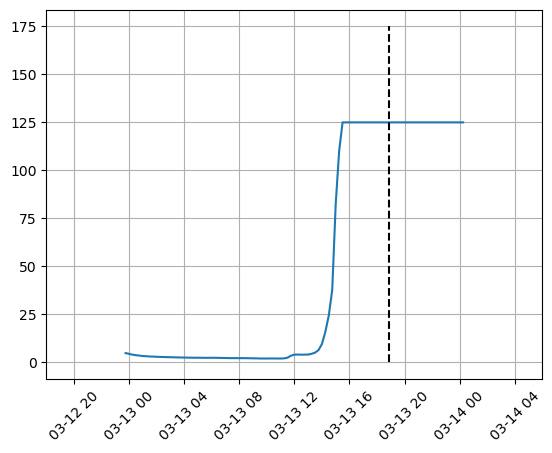

In [3]:
fn = '/scratch/PHM_Simulations/riv_ibwc_raw/restart_data/LV4_ocean_rst_202503130000_202503140000.nc'
t0 = datetime(1999,1,1)
with nc.Dataset(fn) as ds:
    #print(ds)
    print(ds.variables['ocean_time'])
    tsec = ds.variables['ocean_time'][:].data
    t_dt = t0 + tsec * timedelta(seconds=1)
    print(t_dt)
    t_blow = t_dt[-1]

print(t_blow)
#fn = '/dataSIO/PHM_Simulations/riv_ibwc_raw/river_ncs/river_20250313_20250314.nc'
fn = '/scratch/PHM_Simulations/riv_ibwc_raw/LV4_Forecast/Forc/river_20250313_20250314.nc'

with nc.Dataset(fn) as ds:
    t = ds.variables['river_time'][:].data
    Q = 5*ds.variables['river_transport'][:,0].data

t_dt = datetime(1999,1,1,0,0,0) + t*timedelta(days=1)
fig, ax = plt.subplots()
ax.plot(t_dt,-Q)
ax.plot([t_blow,t_blow],[0,175],'--k')
t1 = datetime(2025,3,12,18,0,0)
t2 = datetime(2025,3,14,6,0,0)
plt.xlim(t1,t2)
plt.xticks(rotation=45)
plt.grid(True)

In [ ]:
from scipy.special import erf

def my_exp_filter(q_i):


    dtt=15.0
    ii = np.arange(-1.5*24*60,1.5*24*60 + dtt,dtt)  # 3 full days at 15 min sampling

#    ii = np.arange(-(nF-1)/2,(nF+1)/2)
    nF = len(ii)
    print('the length of the filter is:')
    print(nF)
    i0 = np.argwhere(ii>0)
    nt = len(q_i)
    Q3 = np.zeros(np.shape(q_i))
    TT = np.zeros(np.shape(q_i))
    for a in np.arange(nt):
        if a<(nF-1)/2:
            iq = np.arange( (nF+1)/2 + a )
            iif = np.arange( (nF-1)/2-a,nF)
            #print(a,iq,iif)
        elif a > nt-(nF-1)/2-1:
            iq = np.arange( nt-(nF-1)/2 - (nt-a) ,nt)
            iif = np.arange( 0, nF - a + (nt - (nF-1)/2) - 1 )
            #print(a,iq,iif)
        else:
            iq = np.arange( a - (nF-1)/2, a + (nF+1)/2 )
            iif = np.arange( 0 , nF)
            #print(a,iq,iif)
        
        q0 = q_i[a]
        delta=0.01
        #tau = (erf((q0-150)/20) + 1 + delta) / (2 + delta) / 2.0 # tau in days, need in minutes...
        #
        Qcut = 150 # above which  tau = 0.5
        tau = q0 / (2*Qcut)
        if tau>0.5:
            tau=0.5
        elif tau<0.01:
            tau=0.01

        tau = tau * 24 * 60
        #tau = (erf((q0-150)/20) + 1)
        TT[a] = tau

        F = np.exp( ii  / tau)
        F[i0] = 0
        F2 = F[iif.astype(int)]
        F2 = F2 / np.sum(F2)
        Q2 = q_i[iq.astype(int)]
        Q3[a] = np.sum(F2*Q2)
    
    return Q3, TT



In [10]:
def make_flat_q(qi,qcut):
    # this flattens a time series of qi so that values don't excede qcut
    # it redistributes the flow to later times
    ib = np.argwhere(qi>qcut)
    # need to remove ib if it equals len(qi)
    i_last = np.argwhere( ib == len(qi)-1 )
    if len(i_last)>0:
        ib = np.delete(ib,i_last)
    
    # main loop to move q to later times...
    while len(ib)>0:
        dq = qi-qcut
        q2 = qi.copy()
        q2[ib] = qcut
        q2[ib+1] = q2[ib+1] + dq[ib]
        ib = np.argwhere(q2>qcut)

        if len(ib) > 0:
            i_last = np.argwhere( ib == len(qi)-1 )
            # remove last index.
            if len(i_last)>0:
                ib = np.delete(ib,i_last)
                # hook in case piles up at the end...
                q2[-1]=qcut
                if len(ib) == 1:
                    ib = []
 
        qi = q2

    return qi


In [ ]:
fn_ibwc = '/dataSIO/PHM_Simulations/riv_ibwc_raw/river_ncs/river_20250101_20250102.nc'
fn_vpfm = '/dataSIO/PHM_Simulations/riv_nwm/river_ncs/river_20250101_20250102.nc'
fn_nwm  = '/dataSIO/PHM_Simulations/riv_vpfm/river_ncs/river_20250101_20250102.nc'

date1 = ['20250101','20250102']
date2 = ['20250102','20250103']
types = ['ibwc_raw','nwm','vpfm']



In [2]:

def load_PHM_riverQ_from_nc(fname):
    with nc.Dataset(fname) as ds:
        t = ds.variables['river_time'][0:-1].data
        Q = ds.variables['river_transport'][0:-1,:].data
        t_dt = datetime(1999,1,1,0,0,0) + t*timedelta(days=1)

    return t_dt, Q

def get_PHM_river_flows(phm_version,river_name,t1,t2):
    # this function returns the times and river flows for 3 different PHMs
    # phm_version is one of: 'vpfm','ibwc_raw','nwm'
    # river_name is one of 'TJ','SW','OM','PB'

    if river_name == 'TJ':
        i_riv = 0
        m_riv = -5
    elif river_name == 'SW':
        i_riv = 6
        m_riv = -2
    elif river_name == 'OM':
        i_riv = 8
        m_riv = -1
    elif river_name == 'PB':
        i_riv = 5
        m_riv = -1

    t_tot = np.array([])
    Q = np.array([])
    while t1 <= t2 :
        date1 = t1.strftime('%Y%m%d')
        date2 = (t1 + timedelta(days=1)).strftime('%Y%m%d')
        fn = '/dataSIO/PHM_Simulations/riv_' + phm_version + '/river_ncs/river_' + date1 + '_' + date2 + '.nc'
        tt, Q1 = load_PHM_riverQ_from_nc(fn)
        Q2 = m_riv * Q1[:,i_riv]
        t_tot = np.append(t_tot,tt)
        Q = np.append(Q,Q2)
        t1 = t1 + timedelta(days=1)


    return t_tot, Q

def load_PHM_2d_data_from_nc(fn,vars,ix,iy):
    data_out = dict()
    nx = len(ix)
    with nc.Dataset(fn) as ds:
        t = ds.variables['ocean_time'][0:-1].data
        nt = len(t)
        t_dt = datetime(1999,1,1,0,0,0) + t*timedelta(seconds=1)
        data_out['time'] = t_dt
        for var in vars:
            dum = np.zeros((nt,nx))
            for cnt in np.arange(nx):
                dum[:,cnt] = ds.variables[var][0:-1,iy[cnt],ix[cnt]].data
            
            data_out[var] = dum

    return data_out

def load_PHM_2d_data_from_nc_slice(fn,vars,lat_or_lon,ii):
    data_out = dict()
    with nc.Dataset(fn) as ds:
        t = ds.variables['ocean_time'][0:-1].data
        nt = len(t)
        t_dt = datetime(1999,1,1,0,0,0) + t*timedelta(seconds=1)
        data_out['time'] = t_dt
        for var in vars:
            if lat_or_lon == 'lat':
                dum = np.squeeze( ds.variables[var][0:-1,:,ii].data )
            elif lat_or_lon == 'lon':
                dum = np.squeeze( ds.variables[var][0:-1,ii,:].data )
            
            data_out[var] = dum
    
    del dum
    gc.collect()

    return data_out


def load_PHM_2d_data_from_nc_it(fn,vars,ix,iy,it):
    data_out = dict()
    nx = len(ix)
    with nc.Dataset(fn) as ds:
        t = ds.variables['ocean_time'][it].data
        nt = 1
        t_dt = datetime(1999,1,1,0,0,0) + t*timedelta(seconds=1)
        data_out['time'] = t_dt
        for var in vars:
            dum = np.zeros((nt,nx))
            for cnt in np.arange(nx):
                dum[:,cnt] = ds.variables[var][it,iy[cnt],ix[cnt]].data
            
            data_out[var] = dum

    return data_out

def get_his_jumps(phm_version,LVS,t1,t2,vars,ix,iy):
    t1_tot = np.array([])
    t2_tot = np.array([])
    data1_out = dict()
    data2_out = dict()
    nx = len(ix)
    for lvl in LVS:
        for var in vars:
            data1_out[lvl,var] = np.empty((0,nx))
            data2_out[lvl,var] = np.empty((0,nx))

    while t1 < t2 :
        date1 = t1.strftime('%Y%m%d')
        date2 = (t1 + timedelta(days=1)).strftime('%Y%m%d')

        for lvl in LVS:
            fn1 = '/dataSIO/PHM_Simulations/riv_' + phm_version + '/' + lvl + '/'+ lvl + '_ocean_his_' + date1 + '0000.nc'
            fn2 = '/dataSIO/PHM_Simulations/riv_' + phm_version + '/' + lvl + '/'+ lvl + '_ocean_his_' + date2 + '0000.nc'
            data1 = load_PHM_2d_data_from_nc_it(fn1,vars,ix,iy,-1)
            data2 = load_PHM_2d_data_from_nc_it(fn2,vars,ix,iy,0)
            for var in vars:
                data1_out[lvl,var] = np.append(data1_out[lvl,var],data1[var][:,:], axis = 0)
                data2_out[lvl,var] = np.append(data2_out[lvl,var],data2[var][:,:], axis = 0)

        t1_tot = np.append(t1_tot,data1['time'])
        t2_tot = np.append(t2_tot,data2['time'])
        t1 = t1 + timedelta(days=1)

    del data1, data2
    gc.collect()

    return t1_tot, data1_out, t2_tot, data2_out



def get_PHM_2dvar(phm_version,LVS,t1,t2,vars,ix,iy):
    # this function returns the times and data for the variables vars = ['ubar','zeta',etc]
    # for the levels = ['LV1','LV2',etc]
    # at the indices ix = [ix1,...], iy = [iy1,...] 
    # phm_version is one of: 'vpfm','ibwc_raw','nwm'

    t_tot = np.array([])
    data_out = dict()
    nx = len(ix)
    for lvl in LVS:
        for var in vars:
            data_out[lvl,var] = np.empty((0,nx))

    while t1 <= t2 :
        date1 = t1.strftime('%Y%m%d')

        for lvl in LVS:
            fn = '/dataSIO/PHM_Simulations/riv_' + phm_version + '/' + lvl + '/'+ lvl + '_ocean_his_' + date1 + '0000.nc'
            data_in = load_PHM_2d_data_from_nc(fn,vars,ix,iy)
            for var in vars:
                data_out[lvl,var] = np.append(data_out[lvl,var],data_in[var][:,:], axis = 0)

        t_tot = np.append(t_tot,data_in['time'])
        t1 = t1 + timedelta(days=1)

    del data_in
    gc.collect()

    return t_tot, data_out

def get_his_2d_hov(phm_version,LVS,t1,t2,vars,lat_or_lon,ii):
    # this function returns the times and data for the variables vars = ['ubar','zeta',etc]
    # for the levels = ['LV1','LV2',etc]
    # at the indices ii in the direction lat_or_lon
    # phm_version is one of: 'vpfm','ibwc_raw','nwm'

    t_tot = np.array([])
    data_out = dict()
    for lvl in LVS:
        for var in vars:
            data_out[lvl,var] = np.empty((0,nn))

    cnt = 0
    while t1 <= t2 :
        date1 = t1.strftime('%Y%m%d')
        for lvl in LVS:
            fn = '/dataSIO/PHM_Simulations/riv_' + phm_version + '/' + lvl + '/'+ lvl + '_ocean_his_' + date1 + '0000.nc'
            data_in = load_PHM_2d_data_from_nc_slice(fn,vars,lat_or_lon,ii)
            for var in vars:
                if cnt == 0:
                    data_out[lvl,var] = data_in[var][:,:]
                else:
                    data_out[lvl,var] = np.append(data_out[lvl,var],data_in[var][:,:], axis = 0)

        t_tot = np.append(t_tot,data_in['time'])
        t1 = t1 + timedelta(days=1)
        cnt = cnt + 1

    del data_in
    gc.collect()

    return t_tot, data_out



In [14]:
t1 = datetime(2025,1,1,0,0,0)
t2 = datetime(2025,7,30,0,0,0)
# ilat, ilon is the location, approximately, of SBOO
ilat = 470
ilon = 82
print('getting ibwc LV4 his data...')
_ , data_ibwc_lv4 = get_PHM_2dvar('ibwc_raw',['LV4'],t1,t2,['zeta','vbar','Hwave'],[0,0,ilon],[0,-1,ilat])
print('getting vpfm LV4 his data...')
_ , data_vpfm_lv4 = get_PHM_2dvar('vpfm',['LV4'],t1,t2,['zeta','vbar','Hwave'],[0,0,ilon],[0,-1,ilat])
print('getting nwm LV4 his data...')
time_phm, data_nwm_lv4 = get_PHM_2dvar('nwm',['LV4'],t1,t2,['zeta','vbar','Hwave'],[0,0,ilon],[0,-1,ilat])



getting ibwc LV4 his data...
getting vpfm LV4 his data...
getting nwm LV4 his data...


In [29]:

print('getting nwm LV4 his data...')
time_phm, data_nwm_lv4 = get_PHM_2dvar('nwm',['LV4'],t1,t2,['zeta','vbar','Hwave'],[0,0,ilon],[0,-1,ilat])
print('getting vpfm LV4 his data...')
time_phm, data_vpfm_lv4 = get_PHM_2dvar('vpfm',['LV4'],t1,t2,['zeta','vbar','Hwave'],[0,0,ilon],[0,-1,ilat])


getting nwm LV4 his data...
getting vpfm LV4 his data...


In [3]:
t1 = datetime(2025,1,1,0,0,0)
t2 = datetime(2025,7,30,0,0,0)
# ilat, ilon is the location, approximately, of SBOO
ilat = 470
ilon = 82

print('getting vpfm LV4 his data...')
t1_1, d1_1, t2_1, d2_1 = get_his_jumps('vpfm',['LV4'],t1,t2,['zeta','vbar','Hwave'],[0,0,ilon],[0,0,ilat])
print('getting ibwc LV4 his data...')
t1_2, d1_2, t2_2, d2_2 = get_his_jumps('ibwc_raw',['LV4'],t1,t2,['zeta','vbar','Hwave'],[0,0,ilon],[0,0,ilat])
print('getting nwm LV4 his data...')
t1_3, d1_3, t2_3, d2_3 = get_his_jumps('nwm',['LV4'],t1,t2,['zeta','vbar','Hwave'],[0,0,ilon],[0,0,ilat])
print('getting ibwc_raw LV3 his data...')
t1_4, d1_4, t2_4, d2_4 = get_his_jumps('ibwc_raw',['LV3'],t1,t2,['zeta','vbar'],[0,0,25],[0,0,25])



getting vpfm LV4 his data...
getting ibwc LV4 his data...
getting nwm LV4 his data...
getting ibwc_raw LV3 his data...


Text(0, 0.5, 'zeta [m]')

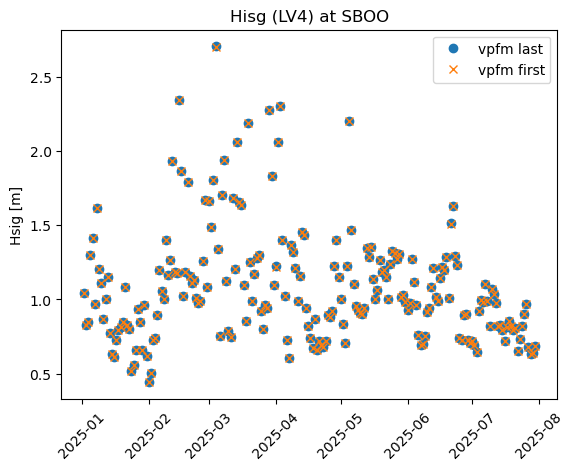

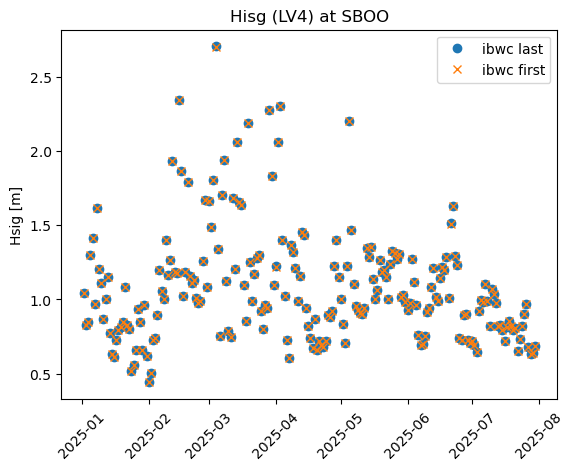

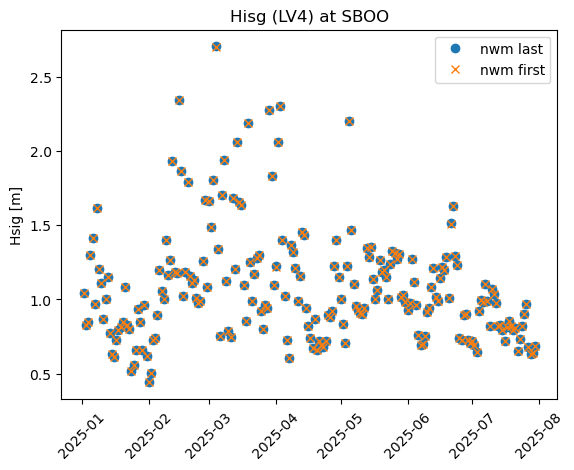

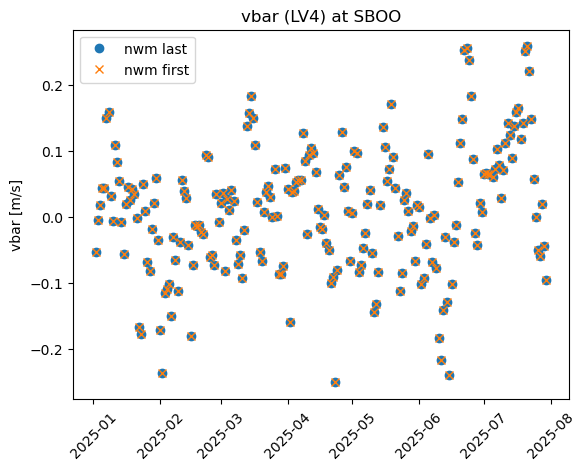

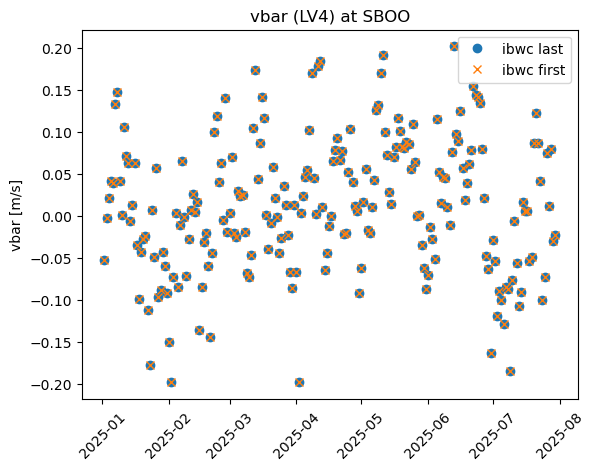

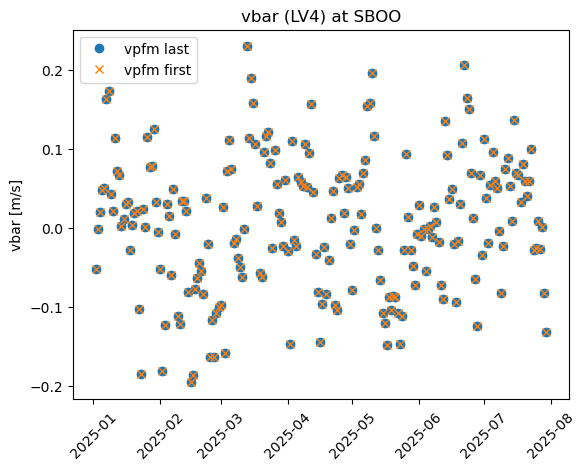

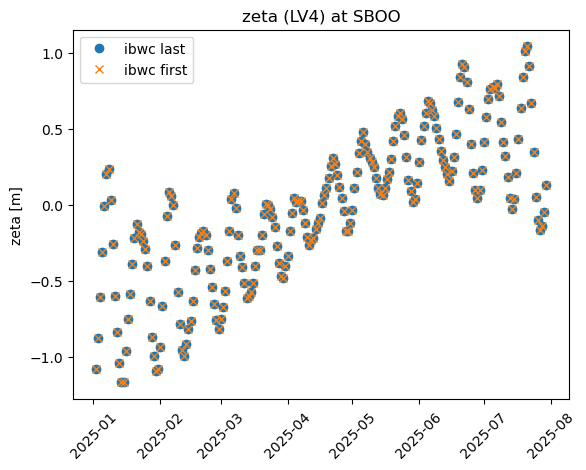

In [4]:
fig, ax = plt.subplots()
var='Hwave'
ax.plot(t1_1,d1_1['LV4',var][:,2],'o',label='vpfm last')
ax.plot(t2_1,d2_1['LV4',var][:,2],'x',label='vpfm first')
plt.legend()
plt.xticks(rotation=45)
plt.title("Hisg (LV4) at SBOO")
plt.ylabel("Hsig [m]")

fig, ax = plt.subplots()
ax.plot(t1_2,d1_2['LV4',var][:,2],'o',label='ibwc last')
ax.plot(t2_2,d2_2['LV4',var][:,2],'x',label='ibwc first')
plt.legend()
plt.xticks(rotation=45)
plt.title("Hisg (LV4) at SBOO")
plt.ylabel("Hsig [m]")

fig, ax = plt.subplots()
ax.plot(t1_3,d1_3['LV4',var][:,2],'o',label='nwm last')
ax.plot(t2_3,d2_3['LV4',var][:,2],'x',label='nwm first')
plt.legend()
plt.xticks(rotation=45)
plt.title("Hisg (LV4) at SBOO")
plt.ylabel("Hsig [m]")

nt = len(t1_1)
for i in np.arange(nt):
    t0 = t1_1[i]
    H1 = d1_1['LV4',var][i,2]
    H2 = d2_1['LV4',var][i,2]
    dH = H2-H1
    if np.abs(dH)>0.005:
        print('for vpfm, the last Hsig for the file')
        print(t0)
        print('doesnt match the 1st Hsig for the next file!\n')
    t0 = t1_2[i]
    H1 = d1_2['LV4',var][i,2]
    H2 = d2_2['LV4',var][i,2]
    dH = H2-H1
    if np.abs(dH)>0.005:
        print('for ibwc, the last Hsig for the file')
        print(t0)
        print('doesnt match the 1st Hsig for the next file!\n')
    t0 = t1_3[i]
    H1 = d1_3['LV4',var][i,2]
    H2 = d2_3['LV4',var][i,2]
    dH = H2-H1
    if np.abs(dH)>0.005:
        print('for nwm, the last Hsig for the file')
        print(t0)
        print('doesnt match the 1st Hsig for the next file!\n')

    t0 = t1_2[i]
    H1 = d1_2['LV4','vbar'][i,2]
    H2 = d2_2['LV4','vbar'][i,2]
    dH = H2-H1
    if np.abs(dH)>0.005:
        print('for ibwc, the last vbar for the file')
        print(t0)
        print('doesnt match the 1st vbar for the next file!\n')


fig, ax = plt.subplots()
ax.plot(t1_3,d1_3['LV4','vbar'][:,2],'o',label='nwm last')
ax.plot(t2_3,d2_3['LV4','vbar'][:,2],'x',label='nwm first')
plt.legend()
plt.xticks(rotation=45)
plt.title("vbar (LV4) at SBOO")
plt.ylabel("vbar [m/s]")

fig, ax = plt.subplots()
ax.plot(t1_2,d1_2['LV4','vbar'][:,2],'o',label='ibwc last')
ax.plot(t2_2,d2_2['LV4','vbar'][:,2],'x',label='ibwc first')
plt.legend()
plt.xticks(rotation=45)
plt.title("vbar (LV4) at SBOO")
plt.ylabel("vbar [m/s]")

fig, ax = plt.subplots()
ax.plot(t1_1,d1_1['LV4','vbar'][:,2],'o',label='vpfm last')
ax.plot(t2_1,d2_1['LV4','vbar'][:,2],'x',label='vpfm first')
plt.legend()
plt.xticks(rotation=45)
plt.title("vbar (LV4) at SBOO")
plt.ylabel("vbar [m/s]")


fig, ax = plt.subplots()
ax.plot(t1_2,d1_2['LV4','zeta'][:,2],'o',label='ibwc last')
ax.plot(t2_2,d2_2['LV4','zeta'][:,2],'x',label='ibwc first')
plt.legend()
plt.xticks(rotation=45)
plt.title("zeta (LV4) at SBOO")
plt.ylabel("zeta [m]")


Text(0, 0.5, 'Delta Hsig [m]')

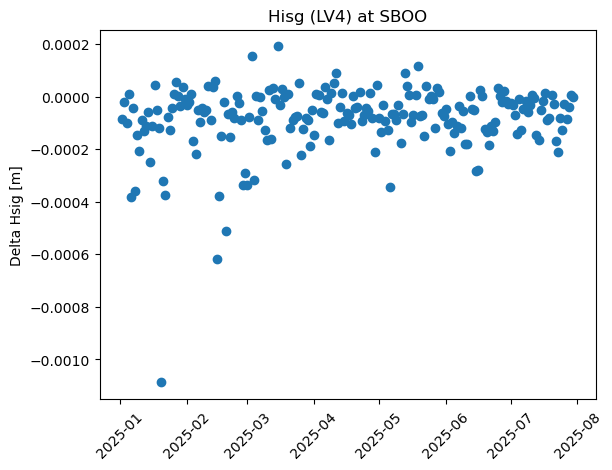

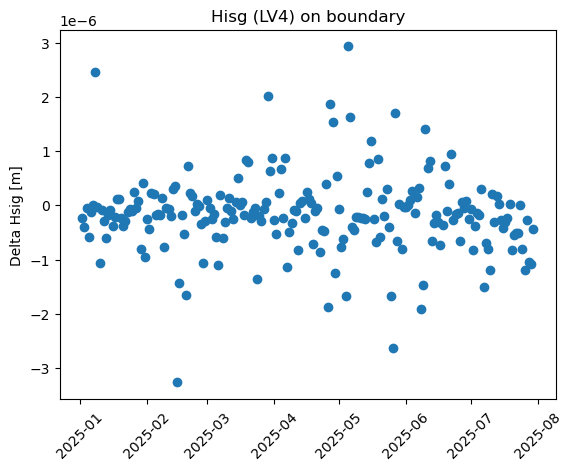

In [13]:
# hopefull this works
var='Hwave'
loc=2
H1 = d1_1['LV4',var][:,loc]
H2 = d2_1['LV4',var][:,loc]
fig, ax = plt.subplots()
ax.plot(t1_1,H2-H1,'o')
plt.xticks(rotation=45)
plt.title("Hisg (LV4) at SBOO")
plt.ylabel("Delta Hsig [m]")


loc=0
H1 = d1_1['LV4',var][:,loc]
H2 = d2_1['LV4',var][:,loc]
fig, ax = plt.subplots()
ax.plot(t1_1,H2-H1,'o')
plt.xticks(rotation=45)
plt.title("Hisg (LV4) on boundary")
plt.ylabel("Delta Hsig [m]")



In [18]:

print('getting ibwc his data...')
_, data_ibwc = get_PHM_2dvar('ibwc_raw',['LV1','LV2','LV3'],t1,t2,['zeta','vbar'],[0,0],[0,-1])
print('getting nwm his data...')
_, data_nwm = get_PHM_2dvar('nwm',['LV1','LV2','LV3'],t1,t2,['zeta','vbar'],[0,0],[0,-1])
print('getting vpfm his data...')
time_phm, data_vpfm = get_PHM_2dvar('vpfm',['LV1','LV2','LV3'],t1,t2,['zeta','vbar'],[0,0],[0,-1])



getting ibwc his data...
getting nwm his data...


: 

Text(0, 0.5, 'vbar [m/s]')

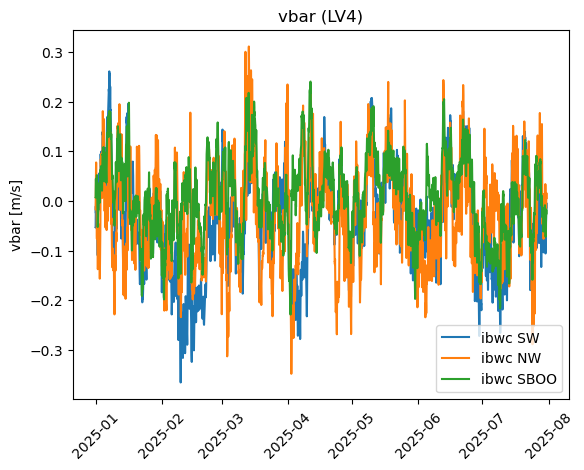

In [15]:

fig, ax = plt.subplots()
ax.plot(time_phm,data_ibwc_lv4['LV4','vbar'][:,0],'-',label='ibwc SW')
ax.plot(time_phm,data_ibwc_lv4['LV4','vbar'][:,1],label='ibwc NW')
ax.plot(time_phm,data_ibwc_lv4['LV4','vbar'][:,2],label='ibwc SBOO')
plt.legend()
plt.xticks(rotation=45)
plt.title("vbar (LV4)")
plt.ylabel("vbar [m/s]")


Text(0, 0.5, 'vbar [m/s]')

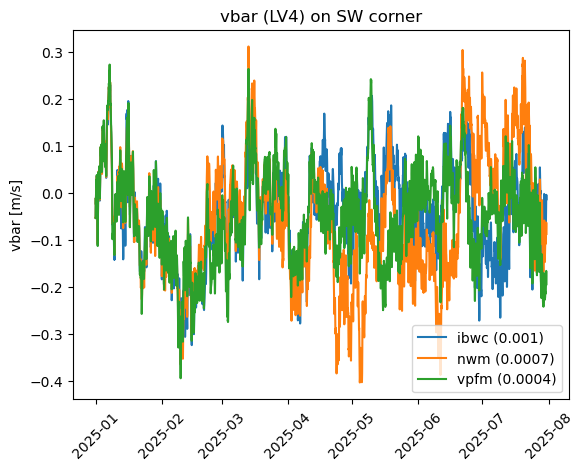

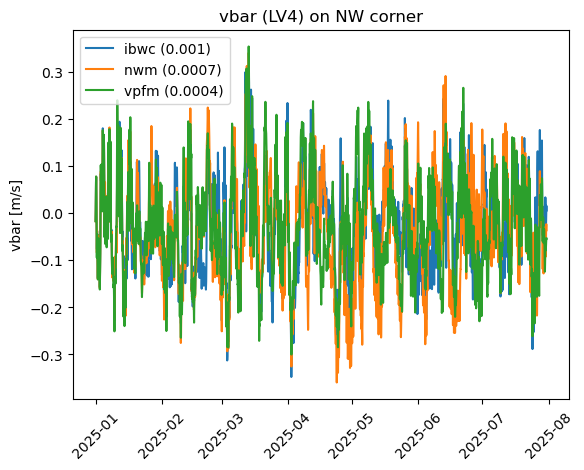

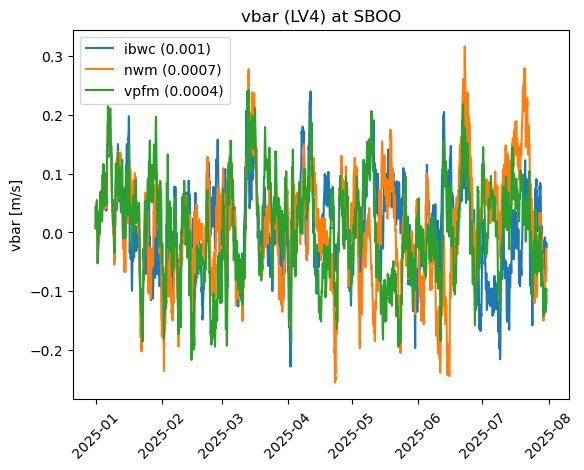

In [16]:


fig, ax = plt.subplots()
ax.plot(time_phm,data_ibwc_lv4['LV4','vbar'][:,0],'-',label='ibwc (0.001)')
ax.plot(time_phm,data_nwm_lv4['LV4','vbar'][:,0],label='nwm (0.0007)')
ax.plot(time_phm,data_vpfm_lv4['LV4','vbar'][:,0],label='vpfm (0.0004)')
plt.legend()
plt.xticks(rotation=45)
plt.title("vbar (LV4) on SW corner")
plt.ylabel("vbar [m/s]")

fig, ax = plt.subplots()
ax.plot(time_phm,data_ibwc_lv4['LV4','vbar'][:,1],label='ibwc (0.001)')
ax.plot(time_phm,data_nwm_lv4['LV4','vbar'][:,1],label='nwm (0.0007)')
ax.plot(time_phm,data_vpfm_lv4['LV4','vbar'][:,1],label='vpfm (0.0004)')
plt.legend()
plt.xticks(rotation=45)
plt.title("vbar (LV4) on NW corner")
plt.ylabel("vbar [m/s]")

fig, ax = plt.subplots()
ax.plot(time_phm,data_ibwc_lv4['LV4','vbar'][:,2],label='ibwc (0.001)')
ax.plot(time_phm,data_nwm_lv4['LV4','vbar'][:,2],label='nwm (0.0007)')
ax.plot(time_phm,data_vpfm_lv4['LV4','vbar'][:,2],label='vpfm (0.0004)')
plt.legend()
plt.xticks(rotation=45)
plt.title("vbar (LV4) at SBOO")
plt.ylabel("vbar [m/s]")


Text(0, 0.5, 'd Hsig [m]')

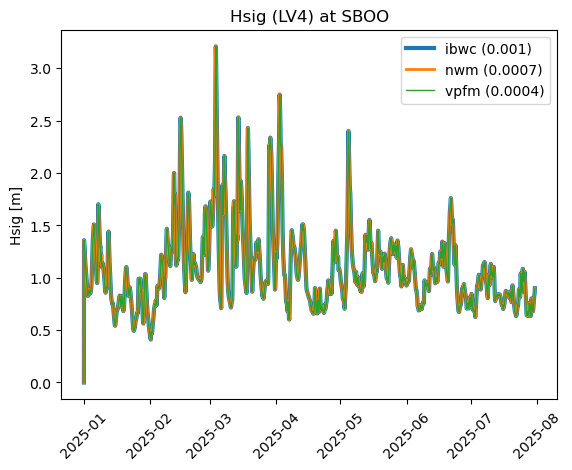

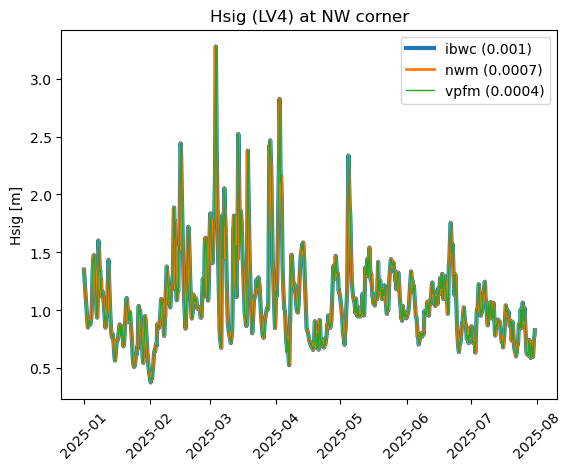

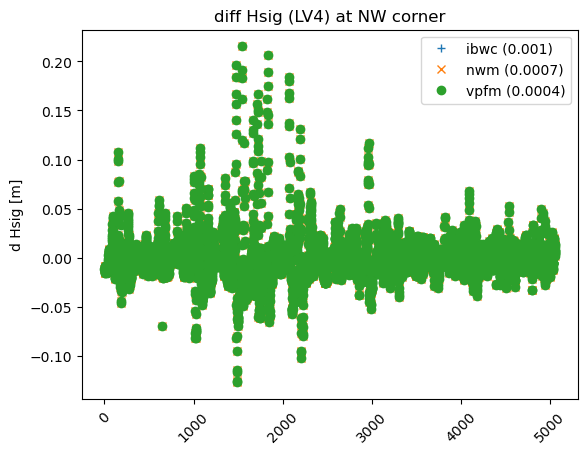

In [17]:
fig, ax = plt.subplots()
ax.plot(time_phm,data_ibwc_lv4['LV4','Hwave'][:,2],label='ibwc (0.001)',linewidth=3)
ax.plot(time_phm,data_nwm_lv4['LV4','Hwave'][:,2],label='nwm (0.0007)',linewidth=2)
ax.plot(time_phm,data_vpfm_lv4['LV4','Hwave'][:,2],label='vpfm (0.0004)',linewidth=1)
plt.legend()
plt.xticks(rotation=45)
plt.title("Hsig (LV4) at SBOO")
plt.ylabel("Hsig [m]")

fig, ax = plt.subplots()
ax.plot(time_phm,data_ibwc_lv4['LV4','Hwave'][:,1],label='ibwc (0.001)',linewidth=3)
ax.plot(time_phm,data_nwm_lv4['LV4','Hwave'][:,1],label='nwm (0.0007)',linewidth=2)
ax.plot(time_phm,data_vpfm_lv4['LV4','Hwave'][:,1],label='vpfm (0.0004)',linewidth=1)
plt.legend()
plt.xticks(rotation=45)
plt.title("Hsig (LV4) at NW corner")
plt.ylabel("Hsig [m]")

fig, ax = plt.subplots()
ax.plot(np.diff( data_ibwc_lv4['LV4','Hwave'][:,1] ),'+',label='ibwc (0.001)')
ax.plot(np.diff( data_nwm_lv4['LV4','Hwave'][:,1] ),'x',label='nwm (0.0007)')
ax.plot(np.diff( data_vpfm_lv4['LV4','Hwave'][:,1] ),'o',label='vpfm (0.0004)')
plt.legend()
plt.xticks(rotation=45)
plt.title("diff Hsig (LV4) at NW corner")
plt.ylabel("d Hsig [m]")



Text(0, 0.5, 'vbar [m/s]')

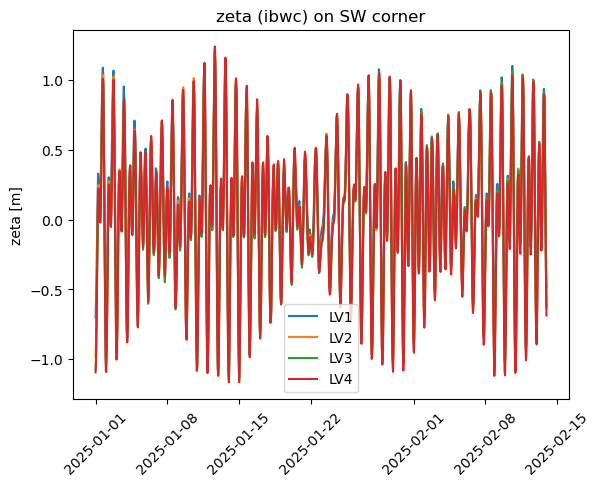

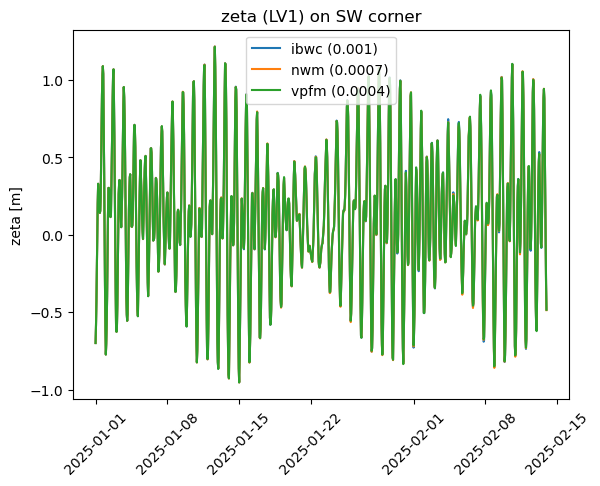

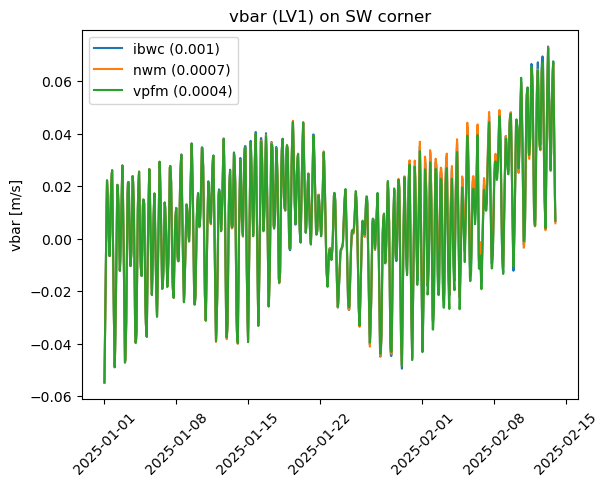

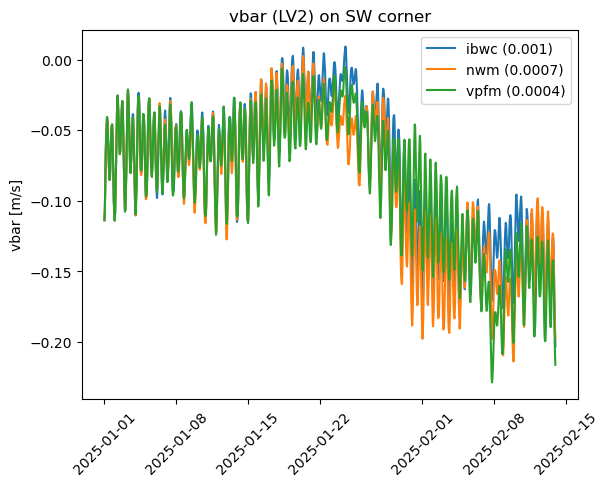

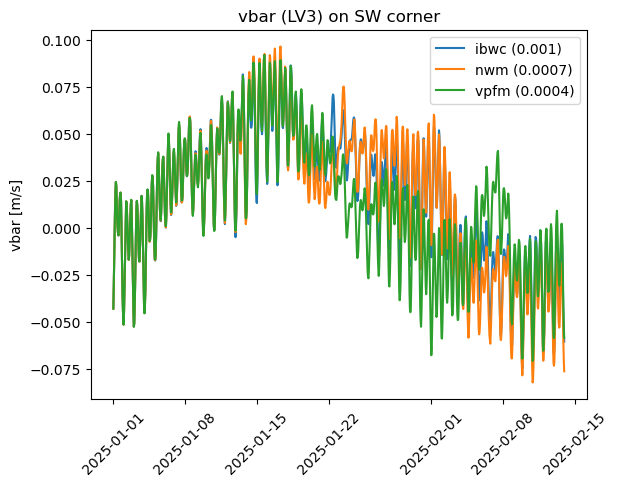

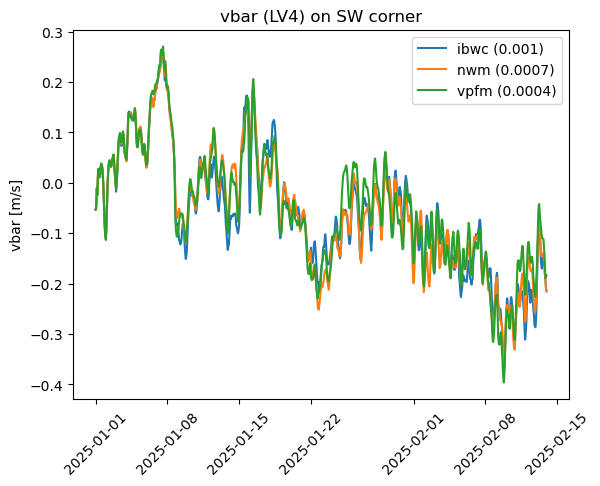

In [ ]:
fig, ax = plt.subplots()
ax.plot(time_phm,data_ibwc['LV1','zeta'][:,0],label='LV1')
ax.plot(time_phm,data_ibwc['LV2','zeta'][:,0],label='LV2')
ax.plot(time_phm,data_ibwc['LV3','zeta'][:,0],label='LV3')
ax.plot(time_phm,data_ibwc_lv4['LV4','zeta'][:,0],label='LV4')
plt.legend()
plt.xticks(rotation=45)
plt.title("zeta (ibwc) on SW corner")
plt.ylabel("zeta [m]")

fig, ax = plt.subplots()
ax.plot(time_phm,data_ibwc['LV1','zeta'][:,0],label='ibwc (0.001)')
ax.plot(time_phm,data_nwm['LV1','zeta'][:,0],label='nwm (0.0007)')
ax.plot(time_phm,data_vpfm['LV1','zeta'][:,0],label='vpfm (0.0004)')
plt.legend()
plt.xticks(rotation=45)
plt.title("zeta (LV1) on SW corner")
plt.ylabel("zeta [m]")

fig, ax = plt.subplots()
ax.plot(time_phm,data_ibwc['LV1','vbar'][:,1],label='ibwc (0.001)')
ax.plot(time_phm,data_nwm['LV1','vbar'][:,1],label='nwm (0.0007)')
ax.plot(time_phm,data_vpfm['LV1','vbar'][:,1],label='vpfm (0.0004)')
plt.legend()
plt.xticks(rotation=45)
plt.title("vbar (LV1) on NW corner")
plt.ylabel("vbar [m/s]")

fig, ax = plt.subplots()
ax.plot(time_phm,data_ibwc['LV2','vbar'][:,0],label='ibwc (0.001)')
ax.plot(time_phm,data_nwm['LV2','vbar'][:,0],label='nwm (0.0007)')
ax.plot(time_phm,data_vpfm['LV2','vbar'][:,0],label='vpfm (0.0004)')
plt.legend()
plt.xticks(rotation=45)
plt.title("vbar (LV2) on SW corner")
plt.ylabel("vbar [m/s]")

fig, ax = plt.subplots()
ax.plot(time_phm,data_ibwc['LV2','vbar'][:,1],label='ibwc (0.001)')
ax.plot(time_phm,data_nwm['LV2','vbar'][:,1],label='nwm (0.0007)')
ax.plot(time_phm,data_vpfm['LV2','vbar'][:,1],label='vpfm (0.0004)')
plt.legend()
plt.xticks(rotation=45)
plt.title("vbar (LV2) on NW corner")
plt.ylabel("vbar [m/s]")


fig, ax = plt.subplots()
ax.plot(time_phm,data_ibwc['LV3','vbar'][:,0],label='ibwc (0.001)')
ax.plot(time_phm,data_nwm['LV3','vbar'][:,0],label='nwm (0.0007)')
ax.plot(time_phm,data_vpfm['LV3','vbar'][:,0],label='vpfm (0.0004)')
plt.legend()
plt.xticks(rotation=45)
plt.title("vbar (LV3) on SW corner")
plt.ylabel("vbar [m/s]")

fig, ax = plt.subplots()
ax.plot(time_phm,data_ibwc['LV3','vbar'][:,1],label='ibwc (0.001)')
ax.plot(time_phm,data_nwm['LV3','vbar'][:,1],label='nwm (0.0007)')
ax.plot(time_phm,data_vpfm['LV3','vbar'][:,1],label='vpfm (0.0004)')
plt.legend()
plt.xticks(rotation=45)
plt.title("vbar (LV3) on NW corner")
plt.ylabel("vbar [m/s]")


Text(0, 0.5, 'vbar [m/s]')

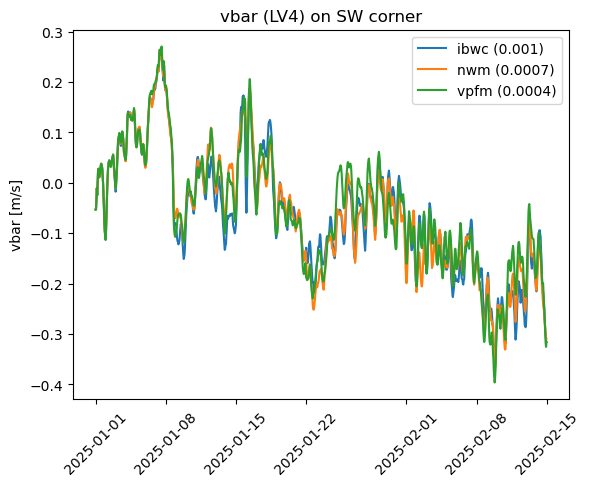

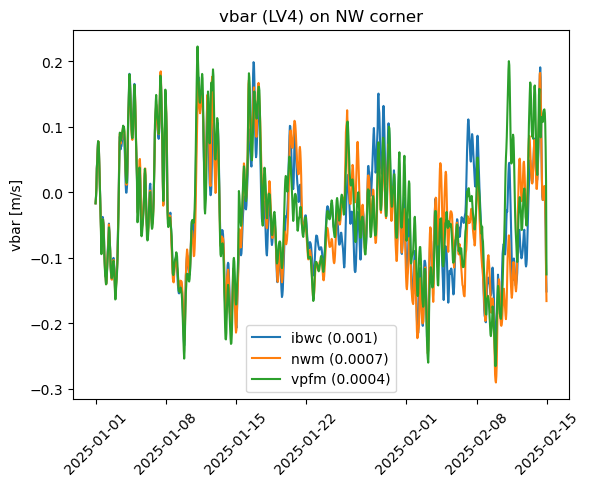

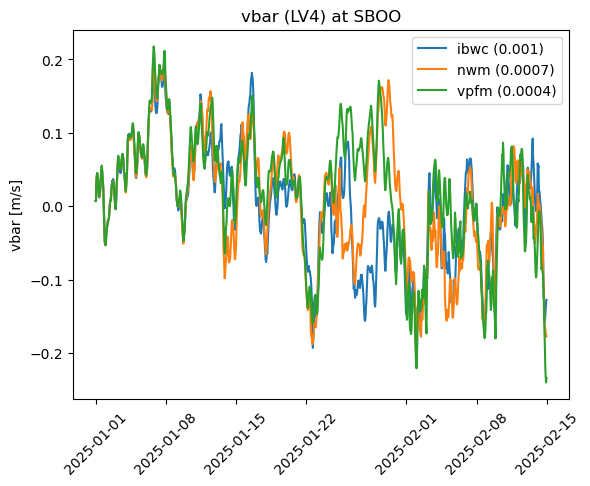

In [62]:


t1 = datetime(2025,1,1,0,0,0)
t2 = datetime(2025,2,13,0,0,0)
riv_name = 'TJ'
time_pfm,Q_pfm = get_PHM_river_flows('vpfm',riv_name,t1,t2)
time_ibwc,Q_ibwc = get_PHM_river_flows('ibwc_raw',riv_name,t1,t2)
time_nwm,Q_nwm = get_PHM_river_flows('nwm',riv_name,t1,t2)


Text(0, 0.5, 'Q [m3/s]')

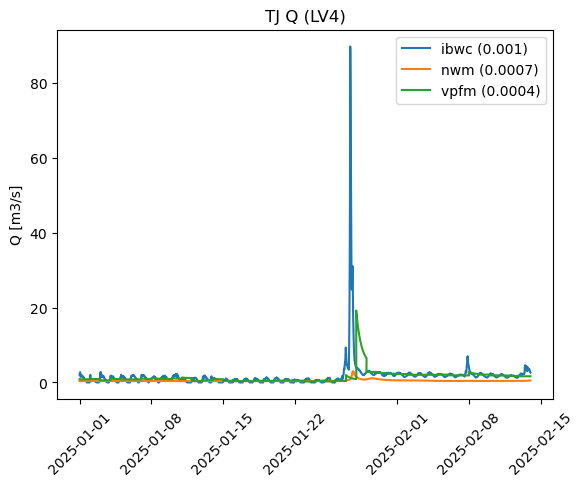

In [63]:

fig, ax = plt.subplots()
ax.plot(time_ibwc,Q_ibwc,label='ibwc (0.001)')
ax.plot(time_nwm,Q_nwm,label='nwm (0.0007)')
ax.plot(time_pfm,Q_pfm,label='vpfm (0.0004)')
plt.legend()
plt.xticks(rotation=45)
plt.title("TJ Q (LV4)")
plt.ylabel("Q [m3/s]")


Text(0, 0.5, 'lat')

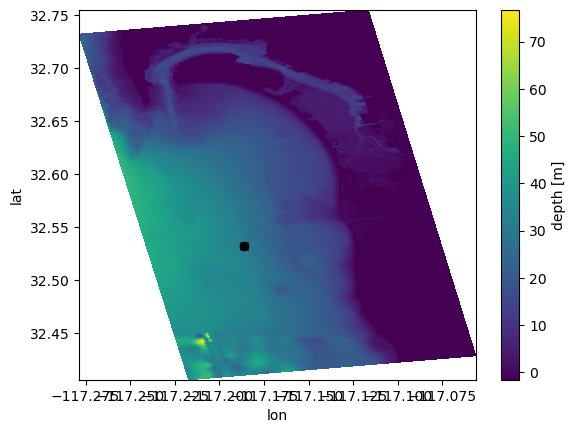

In [ ]:
SBOO = [  32.532040,  -117.186170 ]

fn = '/scratch/PFM_Simulations/Grids/GRID_SDTJRE_LV4_mss_oct2024.nc'
with nc.Dataset(fn) as dsg:
    lat = dsg.variables['lat_rho'][:].data
    lon = dsg.variables['lon_rho'][:].data
    hb  = dsg.variables['h'][:].data

ilat = 470
ilon = 82

fig, ax = plt.subplots()
plt.pcolor(lon, lat, hb, cmap='viridis')
plt.plot(SBOO[1],SBOO[0],'kx')
plt.plot(lon[ilat,ilon],lat[ilat,ilon],'ko')
plt.colorbar(label='depth [m]')
plt.xlabel('lon')
plt.ylabel('lat')



In [5]:
def rm_all_non24hr_swan_rst(sim_type):
    dir0 = '/scratch/PHM_Simulations/riv_' + sim_type + '/restart_data/'
    hrs = ["????????????","????????????_000","????????????_006","????????????_012","????????????_018"]
    for hr in hrs:
        pat = "LV4_swan_rst_" + hr + ".dat*"
        #cmd_lst = ['ls',dir0+pat]
        cmd_txt = 'ls ' + dir0 + pat
        cmd_txt2 = 'rm ' + dir0 + pat
        #print(cmd_txt)
        #result = subprocess.run('ls *.txt', shell=True, capture_output=True, text=True)
        result = subprocess.run(cmd_txt, shell=True, capture_output=True, text=True)
        if result.returncode == 0:
            print("Output:")
            print(result.stdout)
            #result2 = subprocess.run(cmd_txt2, shell=True, capture_output=True, text=True)
            #if result2.returncode == 0:
            #    print("!!! removed files above !!!")
            #else:
            #    print("Error:")
            #    print(result.stderr)        
        else:
            print("Error:")
            print(result.stderr)

def get_list_of_nc_rsts_to_save(sim_type,LV):

    dir0 = '/scratch/PHM_Simulations/riv_' + sim_type + '/restart_data/'
    t0 = datetime(2024,12,31)
    num_weeks = 32
    save_list = []
    for ii in np.arange(num_weeks):
        t1 = t0 +  (ii+1)*7 * timedelta(days=1)
        t2 = t1 + timedelta(days=1)
        t1_str = t1.strftime('%Y%m%d%H%M')
        t2_str = t2.strftime('%Y%m%d%H%M')
        fnm = dir0 + LV + '_ocean_rst_' + t1_str + '_' + t2_str + '.nc'
        save_list.append(fnm)

    return save_list

def get_list_of_nc_rsts(sim_type,LV):
    dir0 = '/scratch/PHM_Simulations/riv_' + sim_type + '/restart_data/'
    nc_files = glob.glob( dir0 + LV + "*.nc" )    
    return nc_files

def delete_unneeded_nc_rst_files(sim_type,LV,time_cut):
    have_list = get_list_of_nc_rsts(sim_type,LV)
    save_list = get_list_of_nc_rsts_to_save(sim_type,LV)
    for fnm in have_list:
        yyyymmdd = get_his_time_from_nc_fnm(fnm)
        tfile = datetime.strptime(yyyymmdd,'%Y%m%d')
        # keep all files after a certain date... (time_cut)
        if tfile < time_cut:
            if fnm in save_list:
                print(fnm,' is in the save list, keeping!')
            else:
                print(fnm,' is not in the save list, deleting!')
                cmd_txt = 'rm ' + fnm
                subprocess.run(cmd_txt,shell=True, capture_output=True, text=True)

def get_list_of_swan_rsts_to_save(sim_type):

    dir0 = '/scratch/PHM_Simulations/riv_' + sim_type + '/restart_data/'
    t0 = datetime(2024,12,31)
    num_weeks = 32
    save_list = []
    for ii in np.arange(num_weeks):
        t1 = t0 +  (ii+1)*7 * timedelta(days=1)
        t1_str = t1.strftime('%Y%m%d%H%M')
        for jj in np.arange(72):
            jj_str = str(jj+1).zfill(3)
            fnm = dir0 + 'LV4_swan_rst_' + t1_str + '_024.dat-' + jj_str
            save_list.append(fnm)

    return save_list

def get_list_of_swan_rsts(sim_type):
    dir0 = '/scratch/PHM_Simulations/riv_' + sim_type + '/restart_data/'
    swan_files = glob.glob( dir0 + "*dat*" )    
    return swan_files

def get_his_time_from_nc_fnm(fnm_full):
    fnm = os.path.basename(fnm_full)    
    yyyymmdd = fnm[14:22]
    return yyyymmdd

def get_swan_time_from_fnm(fnm_full):
    fnm = os.path.basename(fnm_full)
    yyyymmdd = fnm[13:21]
    return yyyymmdd

def delete_unneeded_swan_rst_files(sim_type,time_cut):
    have_list = get_list_of_swan_rsts(sim_type)
    save_list = get_list_of_swan_rsts_to_save(sim_type)
    for fnm in have_list:
        yyyymmdd = get_swan_time_from_fnm(fnm)
        tfile = datetime.strptime(yyyymmdd,'%Y%m%d')
        if tfile < time_cut:
            if fnm in save_list:
                print(fnm,' is in the save list, keeping!')
            else:
                print(fnm,' is not in the save list, deleting!')
                cmd_txt = 'rm ' + fnm
                subprocess.run(cmd_txt,shell=True, capture_output=True, text=True)

def get_list_of_swan_rsts_to_delete(sim_type,yyyymmdd):
    dir0 = '/scratch/PHM_Simulations/riv_' + sim_type + '/restart_data/'
    swan_files = glob.glob( dir0 + "*" + yyyymmdd + "*dat*" )    
    return swan_files

def get_list_of_rsts_to_delete(sim_type,LV,yyyymmdd):
    dir0 = '/scratch/PHM_Simulations/riv_' + sim_type + '/restart_data/'
    rst_files = glob.glob( dir0 + LV + "*" + yyyymmdd + "0000_*.nc" )    
    return rst_files

def delete_swan_rsts_by_yyyymmdd(sim_type,yyyymmdd):
    swan_to_delete = get_list_of_swan_rsts_to_delete(sim_type,yyyymmdd)
    if len(swan_to_delete) > 0:
        for fn in swan_to_delete:
            print('deleting swan file ', fn)
    else:
        print('no swan rsts with this ', yyyymmdd, ' start time.')

def delete_rsts_by_yyyymmdd(sim_type,LV,yyyymmdd):
    rsts_to_delete = get_list_of_rsts_to_delete(sim_type,LV,yyyymmdd)
    if len(rsts_to_delete) > 0:
        for fn in rsts_to_delete:
            print('deleting rst file ', fn)
    else:
        print('no nc rsts with this ', yyyymmdd, ' start time.')



In [6]:
tcut = datetime.strptime('20250401','%Y%m%d')
sim_types = ['ibwc_raw','vpfm','nwm']
LVs = ['LV1','LV2','LV3','LV4']
for sim_type in sim_types:
    print(sim_type)
    for lvl in LVs:
        print(lvl)
        delete_unneeded_nc_rst_files(sim_type,'LV4',tcut)
        if lvl == 'LV4':
            delete_unneeded_swan_rst_files(sim_type,tcut)

ibwc_raw
LV1
/scratch/PHM_Simulations/riv_ibwc_raw/restart_data/LV4_ocean_rst_202503040000_202503050000.nc  is in the save list, keeping!
/scratch/PHM_Simulations/riv_ibwc_raw/restart_data/LV4_ocean_rst_202501070000_202501080000.nc  is in the save list, keeping!
/scratch/PHM_Simulations/riv_ibwc_raw/restart_data/LV4_ocean_rst_202503110000_202503120000.nc  is in the save list, keeping!
/scratch/PHM_Simulations/riv_ibwc_raw/restart_data/LV4_ocean_rst_202501280000_202501290000.nc  is in the save list, keeping!
/scratch/PHM_Simulations/riv_ibwc_raw/restart_data/LV4_ocean_rst_202502110000_202502120000.nc  is in the save list, keeping!
/scratch/PHM_Simulations/riv_ibwc_raw/restart_data/LV4_ocean_rst_202502040000_202502050000.nc  is in the save list, keeping!
/scratch/PHM_Simulations/riv_ibwc_raw/restart_data/LV4_ocean_rst_202503250000_202503260000.nc  is in the save list, keeping!
/scratch/PHM_Simulations/riv_ibwc_raw/restart_data/LV4_ocean_rst_202502250000_202502260000.nc  is in the save li

In [ ]:
sim_type = 'vpfm'
yyyymmdd = '20250301'
LV = 'LV1'
delete_rsts_by_yyyymmdd(sim_type,LV,yyyymmdd)
delete_swan_rsts_by_yyyymmdd(sim_type,yyyymmdd)


deleting rst file  /scratch/PHM_Simulations/riv_vpfm/restart_data/LV1_ocean_rst_202503010000_202503020000.nc
deleting swan file  /scratch/PHM_Simulations/riv_vpfm/restart_data/LV4_swan_rst_202503010000_018.dat-016
deleting swan file  /scratch/PHM_Simulations/riv_vpfm/restart_data/LV4_swan_rst_202503010000_006.dat-003
deleting swan file  /scratch/PHM_Simulations/riv_vpfm/restart_data/LV4_swan_rst_202503010000_000.dat-019
deleting swan file  /scratch/PHM_Simulations/riv_vpfm/restart_data/LV4_swan_rst_202503010000_018.dat-050
deleting swan file  /scratch/PHM_Simulations/riv_vpfm/restart_data/LV4_swan_rst_202503010000_006.dat-023
deleting swan file  /scratch/PHM_Simulations/riv_vpfm/restart_data/LV4_swan_rst_202503010000_000.dat-015
deleting swan file  /scratch/PHM_Simulations/riv_vpfm/restart_data/LV4_swan_rst_202503010000_024.dat-039
deleting swan file  /scratch/PHM_Simulations/riv_vpfm/restart_data/LV4_swan_rst_202503010000_006.dat-039
deleting swan file  /scratch/PHM_Simulations/riv_vp

: 

In [53]:
f1_full = '/scratch/PHM_Simulations/riv_vpfm/restart_data/LV4_swan_rst_202502250000_024.dat-071'
f2_full = '/scratch/PHM_Simulations/riv_vpfm/restart_data/LV4_ocean_rst_202503010000_202503020000.nc'

f1 = os.path.basename(f1_full) 
f2 = os.path.basename(f2_full) 

print(f1[13:21])
print(f2[14:22])

20250225
20250301


In [61]:
sim_type = 'vpfm'
tcut = datetime.strptime('20250301','%Y%m%d')

#save_list = get_list_of_swan_rsts_to_save(sim_type)
#print(save_list)
#have_list = get_list_of_nc_rsts(sim_type,LV)
#print(have_list)

delete_unneeded_nc_rst_files(sim_type,'LV1',tcut)
delete_unneeded_nc_rst_files(sim_type,'LV2',tcut)
delete_unneeded_nc_rst_files(sim_type,'LV3',tcut)
delete_unneeded_nc_rst_files(sim_type,'LV4',tcut)
delete_unneeded_swan_rst_files(sim_type,tcut)

/scratch/PHM_Simulations/riv_vpfm/restart_data/LV1_ocean_rst_202501240000_202501250000.nc  is not in the save list, deleting!
/scratch/PHM_Simulations/riv_vpfm/restart_data/LV1_ocean_rst_202501070000_202501080000.nc  is in the save list, keeping!
/scratch/PHM_Simulations/riv_vpfm/restart_data/LV1_ocean_rst_202501100000_202501110000.nc  is not in the save list, deleting!
/scratch/PHM_Simulations/riv_vpfm/restart_data/LV1_ocean_rst_202501310000_202502010000.nc  is not in the save list, deleting!
/scratch/PHM_Simulations/riv_vpfm/restart_data/LV1_ocean_rst_202501220000_202501230000.nc  is not in the save list, deleting!
/scratch/PHM_Simulations/riv_vpfm/restart_data/LV1_ocean_rst_202502010000_202502020000.nc  is not in the save list, deleting!
/scratch/PHM_Simulations/riv_vpfm/restart_data/LV1_ocean_rst_202502140000_202502150000.nc  is not in the save list, deleting!
/scratch/PHM_Simulations/riv_vpfm/restart_data/LV1_ocean_rst_202501130000_202501140000.nc  is not in the save list, deletin

Output:
/scratch/PHM_Simulations/riv_ibwc_raw/restart_data/LV4_swan_rst_202502280000.dat-001
/scratch/PHM_Simulations/riv_ibwc_raw/restart_data/LV4_swan_rst_202502280000.dat-002
/scratch/PHM_Simulations/riv_ibwc_raw/restart_data/LV4_swan_rst_202502280000.dat-003
/scratch/PHM_Simulations/riv_ibwc_raw/restart_data/LV4_swan_rst_202502280000.dat-004
/scratch/PHM_Simulations/riv_ibwc_raw/restart_data/LV4_swan_rst_202502280000.dat-005
/scratch/PHM_Simulations/riv_ibwc_raw/restart_data/LV4_swan_rst_202502280000.dat-006
/scratch/PHM_Simulations/riv_ibwc_raw/restart_data/LV4_swan_rst_202502280000.dat-007
/scratch/PHM_Simulations/riv_ibwc_raw/restart_data/LV4_swan_rst_202502280000.dat-008
/scratch/PHM_Simulations/riv_ibwc_raw/restart_data/LV4_swan_rst_202502280000.dat-009
/scratch/PHM_Simulations/riv_ibwc_raw/restart_data/LV4_swan_rst_202502280000.dat-010
/scratch/PHM_Simulations/riv_ibwc_raw/restart_data/LV4_swan_rst_202502280000.dat-011
/scratch/PHM_Simulations/riv_ibwc_raw/restart_data/LV4_sw

In [ ]:


t1 = datetime(2025,1,1,0,0,0)
t2 = datetime(2025,2,5,0,0,0)
riv_name = 'PB'
time_pfm,Q_pfm = get_PHM_river_flows('vpfm',riv_name,t1,t2)
time_ibwc,Q_ibwc = get_PHM_river_flows('ibwc_raw',riv_name,t1,t2)
time_nwm,Q_nwm = get_PHM_river_flows('nwm',riv_name,t1,t2)

fig, ax = plt.subplots()
ax.plot(time_pfm,Q_pfm)
ax.plot(time_ibwc,Q_ibwc)
ax.plot(time_nwm,Q_nwm)


In [ ]:



fig, ax = plt.subplots()

cnt = 0
clrs = ['k','g','r']
for date in date1:
    cntc = 0
    for type in types:
        fn = '/dataSIO/PHM_Simulations/riv_' + type + '/river_ncs/river_' + date + '_' + date2[cnt] + '.nc'

        with nc.Dataset(fn) as ds:
            t = ds.variables['river_time'][:].data
            Q = 5*ds.variables['river_transport'][:,0].data
            print(Q[0],Q[-1])

        t_dt = datetime(1999,1,1,0,0,0) + t*timedelta(days=1)
        ax.plot(t_dt, -Q ,label = fn, color = clrs[cntc])
        cntc=cntc+1

    cnt = cnt+1

# Add the title
plt.title("TJR discharge for 3 PHM simulations")
# Add the y-axis label
plt.ylabel("Q [m3/s]")
# Rotate x-tick labels by 45 degrees
plt.xticks(rotation=45)


['TJR' 'Otay' 'SW']
0.3899999912828207 0.3799999915063381
9497.0 9497.958333333334
['TJR' 'Otay' 'SW']
0.36999999172985554 0.36999999172985554
9498.0 9498.958333333334
['TJR' 'Otay' 'SW']
0.36999999172985554 0.3899999912828207
9499.0 9499.958333333334


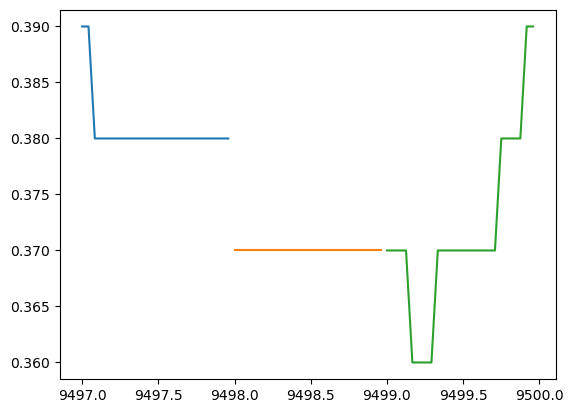

In [4]:
fig, ax = plt.subplots()
fn_nwm1 = '/dataSIO/PHM_Simulations/raw_download/nwm_files/nwm_assim_20250101.nc'
fn_nwm2 = '/dataSIO/PHM_Simulations/raw_download/nwm_files/nwm_assim_20250102.nc'
fn_nwm3 = '/dataSIO/PHM_Simulations/raw_download/nwm_files/nwm_assim_20250103.nc'
for fn in [fn_nwm1,fn_nwm2,fn_nwm3]:    
    with nc.Dataset(fn) as ds:
        print(ds.variables['station_id'][:])
        t = ds.variables['time'][:].data
        Q = ds.variables['discharge'][:,0].data
        print(Q[0],Q[-1])
        print(t[0],t[-1])

    ax.plot(t, Q)


[0.38999999 0.38999999 0.37999999 0.37999999 0.37999999 0.37999999
 0.37999999 0.37999999 0.37999999 0.37999999 0.37999999 0.37999999
 0.37999999 0.37999999 0.37999999 0.37999999 0.37999999 0.37999999
 0.37999999 0.37999999 0.37999999 0.37999999 0.37999999 0.37999999
 0.36999999 0.36999999 0.36999999 0.36999999 0.36999999 0.36999999
 0.36999999 0.36999999 0.36999999 0.36999999 0.36999999 0.36999999
 0.36999999 0.36999999 0.36999999 0.36999999 0.36999999 0.36999999
 0.36999999 0.36999999 0.36999999 0.36999999 0.36999999 0.36999999
 0.36999999 0.36999999 0.36999999 0.36999999 0.35999999 0.35999999
 0.35999999 0.35999999 0.36999999 0.36999999 0.36999999 0.36999999
 0.36999999 0.36999999 0.36999999 0.36999999 0.36999999 0.36999999
 0.37999999 0.37999999 0.37999999 0.37999999 0.38999999 0.38999999]


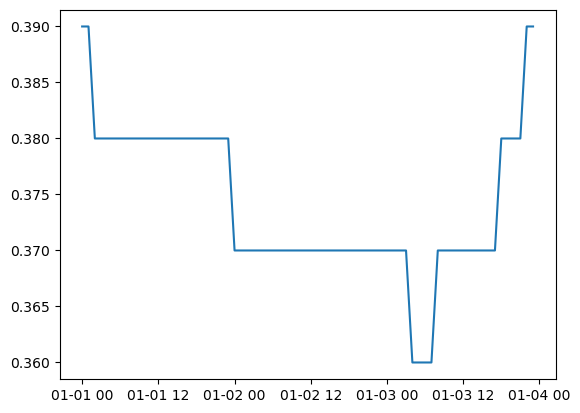

In [5]:
fnames = [fn_nwm1,fn_nwm2,fn_nwm3]
t_nc, q_nc, rid_nc = riverfuns.get_data_from_nwm_nc_files(fnames)

fig, ax = plt.subplots()
ax.plot(t_nc, q_nc[:,0])

print(q_nc[:,0])


In [ ]:
t0 = datetime(2025,1,1,0,0,0)
nday  = 1   
t2 = t0 + nday * timedelta(days=1)
dt_riv = timedelta(minutes=15) # this is the dt for the river file
t_riv = np.arange(t0-dt_riv,t2+2*dt_riv,dt_riv)
info_pkl="/scratch/PHM_Simulations/phm_vpfm.pkl"

q_sw, q_om, q_tjnwm = riverfuns.get_nwm_analysis_flow(t_riv,info_pkl)
print(q_tjnwm)



/dataSIO/PHM_Simulations/raw_download/nwm_files/nwm_assim_20241231.nc  exists. No need to download.
/dataSIO/PHM_Simulations/raw_download/nwm_files/nwm_assim_20250101.nc  exists. No need to download.
/dataSIO/PHM_Simulations/raw_download/nwm_files/nwm_assim_20250102.nc  exists. No need to download.
need to get the data from the nc files...
[0.38999999 0.38999999 0.38999999 0.38999999 0.38999999 0.38999999
 0.38749999 0.38499999 0.38249999 0.37999999 0.37999999 0.37999999
 0.37999999 0.37999999 0.37999999 0.37999999 0.37999999 0.37999999
 0.37999999 0.37999999 0.37999999 0.37999999 0.37999999 0.37999999
 0.37999999 0.37999999 0.37999999 0.37999999 0.37999999 0.37999999
 0.37999999 0.37999999 0.37999999 0.37999999 0.37999999 0.37999999
 0.37999999 0.37999999 0.37999999 0.37999999 0.37999999 0.37999999
 0.37999999 0.37999999 0.37999999 0.37999999 0.37999999 0.37999999
 0.37999999 0.37999999 0.37999999 0.37999999 0.37999999 0.37999999
 0.37999999 0.37999999 0.37999999 0.37999999 0.37999999

In [7]:
fn_qtj_obs = '/dataSIO/PHM_Simulations/raw_download/qtj_obs_data/qtj_raw_20200101_20250901.csv'
t_tj_raw, q_tj_raw = riverfuns.get_all_tj_observed_data(fn_qtj_obs)
t_original = (t_tj_raw.astype('datetime64[ns]')).astype('int64')

t0 = datetime(2025,1,1,0,0,0)
t2 = datetime(2025,9,1,0,0,0)
dt_riv = timedelta(minutes=15) # this is the dt for the river file
t_riv = np.arange(t0,t2+dt_riv,dt_riv)

t_i = (t_riv.astype('datetime64[ns]')).astype('int64')
q_tj_i = np.interp(t_i, t_original, q_tj_raw)

print(np.shape(t_i))
print(np.shape(t_original))
print(np.shape(q_tj_i))



(23329,)
(198428,)
(23329,)


In [8]:
def get_daily_max_Q(t_tj,Q_tj):
    
    t1 = datetime(2025,1,1,0,0)
    t2 = datetime(2025,8,31,0,0,0)


    t_daily = []
    q_max = []
    while t1 <= t2:
        t1_64 = np.datetime64(t1,'ns')
        msk = (t_tj>=t1_64) & (t_tj<t1_64+np.timedelta64(1, 'D'))
        iday = np.argwhere( msk )
        q_max.append( np.max( Q_tj[iday]))
        t_daily.append( t1 )
        t1 = t1 + timedelta(days=1)

    q_max = np.array( q_max )
    t_daily = np.array( t_daily )
    return t_daily, q_max

[[26]
 [44]
 [71]
 [72]]
[[ 89.76317595]
 [150.        ]
 [150.        ]
 [150.        ]]
[[datetime.datetime(2025, 1, 27, 0, 0)]
 [datetime.datetime(2025, 2, 14, 0, 0)]
 [datetime.datetime(2025, 3, 13, 0, 0)]
 [datetime.datetime(2025, 3, 14, 0, 0)]]
36922.2035518449
36898.302868569546
36918.3615974443
36922.2035518449
Number of NaNs in q_tj_i: 0
Number of NaNs in Q3: 0


(0.0, 20.0)

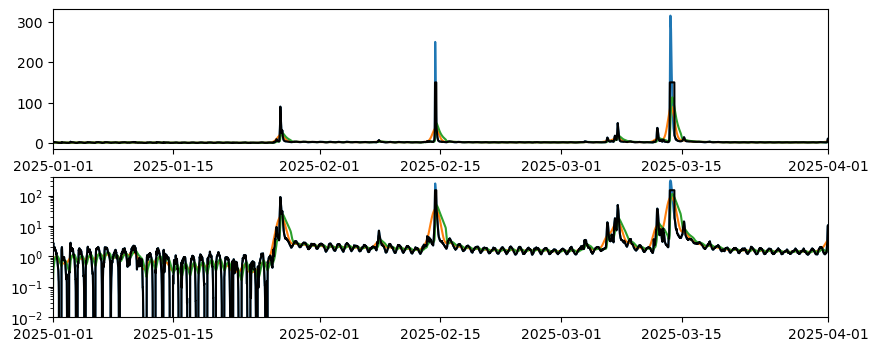

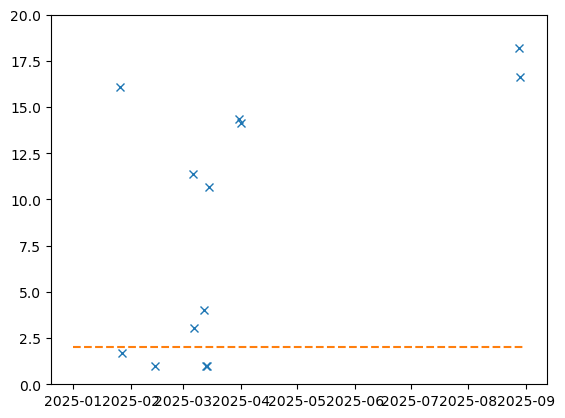

In [11]:

dtt=15.0
TF=.5*24*60
ii = np.arange(-2.5*TF,2.5*TF + dtt,dtt)  # in minutes!
Fg =  np.exp( - np.square(ii) / np.square(TF) )
Fg = Fg / np.sum(Fg)
Qg = np.convolve(q_tj_i,Fg,mode='same')
Fe = np.exp( - ii / TF )
ib = np.argwhere((Fe>1))
Fe[ib] = 0
Fe = Fe / np.sum(Fe)
Qe = np.convolve(q_tj_i,Fe,mode='same')
Qmax = 200
alpha =  q_tj_i / Qmax 
i1 = np.argwhere( alpha > 1)

Q3 = make_flat_q(q_tj_i,150)


t_i2 = t_i.astype('datetime64[ns]') 

tmx, qmax = get_daily_max_Q(t_i2,Q3)
dt_lv4 = 150.0 / qmax

i_sm = np.argwhere( (dt_lv4 < 2.0) )
print(i_sm)
print(qmax[i_sm])
print(tmx[i_sm])


fig, (ax1,ax2) = plt.subplots(nrows=2, ncols=1, figsize=(10, 4))
ax1.plot(t_i2,q_tj_i)
ax1.plot(t_i2,Qg)
ax1.plot(t_i2,Qe)
ax1.plot(t_i2,Q3,'k')

t1 = datetime(2025,1,1)
t2 = datetime(2025,4,1)
ax1.set_xlim(t1,t2)

ax2.semilogy(t_i2,q_tj_i)
ax2.semilogy(t_i2,Qg)
ax2.semilogy(t_i2,Qe)
ax2.semilogy(t_i2,Q3,'k')
ax2.set_xlim(t1,t2)
ax2.set_ylim(1/100,400)

print(np.sum(q_tj_i))
print(np.sum(Qg))
print(np.sum(Qe))
print(np.sum(Q3))

nan_count = np.count_nonzero(np.isnan(q_tj_i))
print(f"Number of NaNs in q_tj_i: {nan_count}")
nan_count = np.count_nonzero(np.isnan(Q3))
print(f"Number of NaNs in Q3: {nan_count}")


fig, ax = plt.subplots()
ax.plot(tmx,dt_lv4,'x',linewidth=.5)
ax.plot(tmx,2*dt_lv4 / dt_lv4, '--')
ax.set_ylim(0,20)



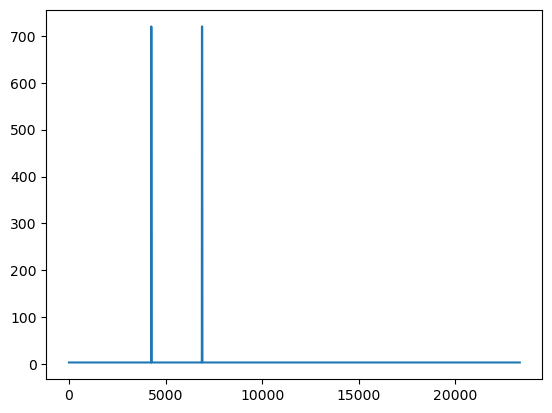

(np.float64(20089.0), np.float64(20332.0))

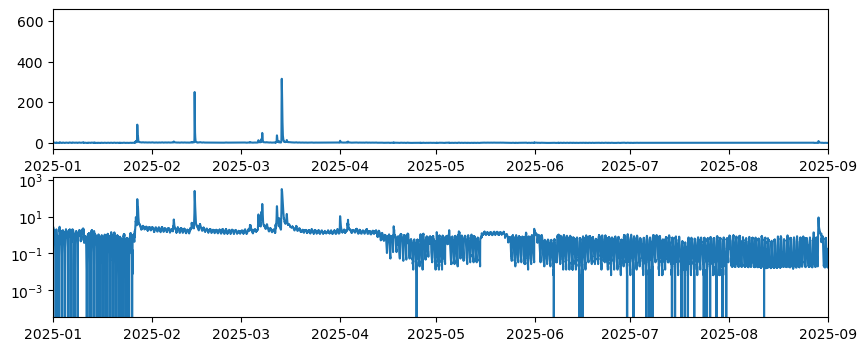

In [ ]:

fig, (ax1,ax2) = plt.subplots(nrows=2, ncols=1, figsize=(10, 4))
ax1.plot(t_tj_raw,q_tj_raw)
t1 = datetime(2025,1,1)
t2 = datetime(2025,9,1)
ax1.set_xlim(t1,t2)
ax2.semilogy(t_tj_raw,q_tj_raw)
ax2.set_xlim(t1,t2)

#ax2.set_xticks(rotation=45)


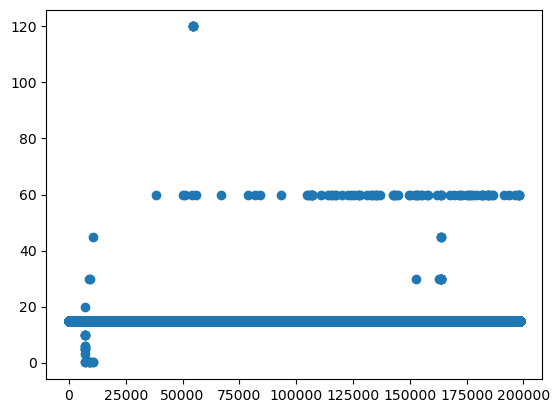

In [19]:
dt = []
for cnt in np.arange(len(t_tj_raw)-1):
    dt1 = t_tj_raw[cnt+1] - t_tj_raw[cnt]
    dt.append(dt1.total_seconds() / 60.0 )

fig, ax = plt.subplots()
ax.plot(dt,'o')



In [13]:
sim_start_time = '2025012100'
if (sim_start_time == '2025010100') or (sim_start_time == '2025012100'):
    print('in here')
else:
    print('not!')


in here


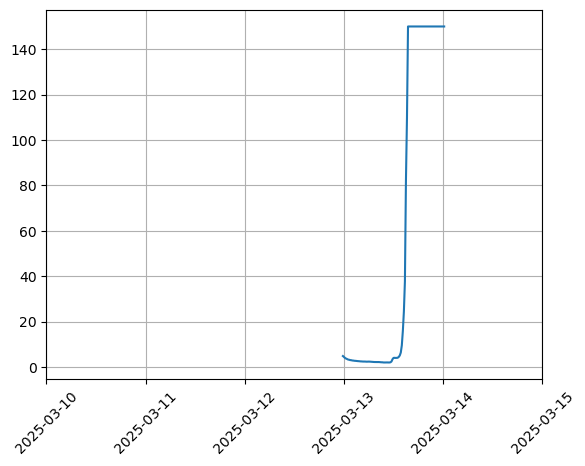

(array([20179., 20193., 20209., 20223., 20240.]),
 [Text(20179.0, 0, '2025-04-01'),
  Text(20193.0, 0, '2025-04-15'),
  Text(20209.0, 0, '2025-05-01'),
  Text(20223.0, 0, '2025-05-15'),
  Text(20240.0, 0, '2025-06-01')])

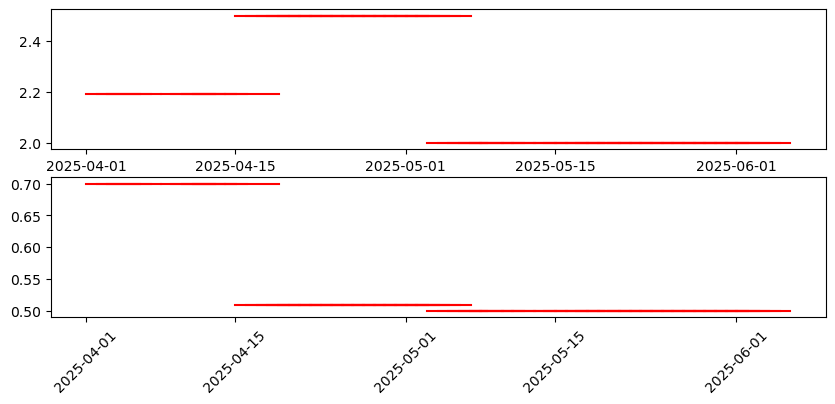

In [ ]:
t1 = '2025040100'
t2 = '2025060100'
dir0 = '/dataSIO/PFM_Simulations/Archive/Forcing/'
t0 = datetime.strptime(t1,'%Y%m%d%H')
tend = datetime.strptime(t2,'%Y%m%d%H')
fig, (ax1,ax2) = plt.subplots(nrows=2, ncols=1, figsize=(10, 4))

while t0 <= tend:
    t_str = t0.strftime('%Y%m%d%H')
    f_name = dir0 + 'river_LV4_' + t_str + '.nc'
    if os.path.exists(f_name):
        with nc.Dataset(f_name) as ds:
            t = ds.variables['river_time'][:].data
            t_dt = datetime(1999,1,1,0,0,0) + t * timedelta(days=1)
            Q_tj = -5*ds.variables['river_transport'][:,0].data
            Q_pb = -ds.variables['river_transport'][:,5].data
            dye_pb = ds.variables['river_dye_01'][:,0,5].data
            dye_tj = ds.variables['river_dye_02'][:,0,0].data
            #ax1.plot(t_dt,Q_tj,'k')
            ax1.plot(t_dt,Q_pb,'r')
            #ax2.plot(t_dt,dye_tj,'k')
            ax2.plot(t_dt,dye_pb,'r')
            
            
         
    t0 = t0 + timedelta(days=1)

plt.xticks(rotation=45)





In [113]:
from scipy.special import erf

def my_exp_filter(q_i):

    dtt=15.0
    ii = np.arange(-1.25*24*60,1.25*24*60 + dtt,dtt)  # 2.5 full days at 15 min sampling

#    ii = np.arange(-(nF-1)/2,(nF+1)/2)
    nF = len(ii)
    print('the length of the filter is:')
    print(nF)
    i0 = np.argwhere(ii>0)
    nt = len(q_i)
    Q3 = np.zeros(np.shape(q_i))
    for a in np.arange(nt):
        if a<(nF-1)/2:
            iq = np.arange( (nF+1)/2 + a )
            iif = np.arange( (nF-1)/2-a,nF)
            #print(a,iq,iif)
        elif a > nt-(nF-1)/2-1:
            iq = np.arange( nt-(nF-1)/2 - (nt-a) ,nt)
            iif = np.arange( 0, nF - a + (nt - (nF-1)/2) - 1 )
            #print(a,iq,iif)
        else:
            iq = np.arange( a - (nF-1)/2, a + (nF+1)/2 )
            iif = np.arange( 0 , nF)
            #print(a,iq,iif)
        
        q0 = q_i[0]
        tau = .25* (erf((q0-150)/20) + 1) # tau in days, need in minutes...
        tau = tau * 24 * 60
        #tau = (erf((q0-150)/20) + 1)


        F = np.exp( ii  / tau)
        F[i0] = 0
        F2 = F[iif.astype(int)]
        F2 = F2 / np.sum(F2)
        Q2 = q_i[iq.astype(int)]
        Q3[a] = np.sum(F2*Q2)
    
    return Q3


In [154]:
q_i = np.array([0,120,0,0,0,120,170,190,180,150,100,0,0,0,0,160])
q2 = make_flat_q(q_i,150)

print(q_i)
print(q2)
print(np.sum(q_i))
print(np.sum(q2))



[  0 120   0   0   0 120 170 190 180 150 100   0   0   0   0 160]
[  0 120   0   0   0 120 150 150 150 150 150  40   0   0   0 150]
1190
1180


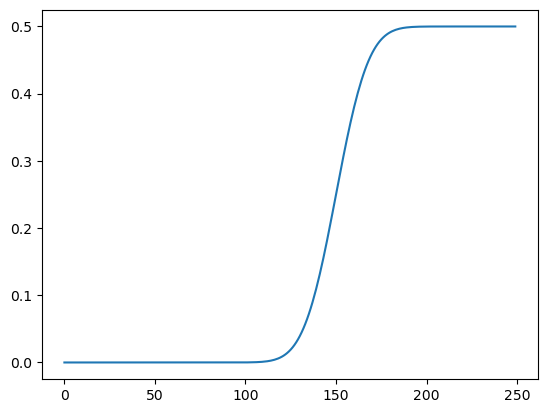

In [105]:
from scipy.special import erf


qq = np.arange(0,250)
tau = .25* (erf((qq-150)/20) + 1)
fig, ax = plt.subplots()
ax.plot(qq,tau)

